## Generar espectros

In [1]:
import multirex as mrex
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import pandas as pd
import os
import re
import gc
import warnings
import joblib

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def remove_warnings():
    warnings.filterwarnings("ignore", category=DeprecationWarning)

from sklearn.model_selection import train_test_split

waves=np.loadtxt("waves.txt")
n_points = len(waves)
indices = np.linspace(0, len(waves) - 1, n_points, endpoint=True)
indices = np.round(indices).astype(int)  # Redondear los índices y convertir a entero

# Seleccionar los elementos de la lista usando los índices
puntos_seleccionados = waves[indices]
waves=puntos_seleccionados
wn_grid=np.sort((10000/waves))

Loading MultiREx version 0.3.1


## load data

In [2]:
import os
import re
import numpy as np
import pandas as pd

def apply_contaminations_from_files(contamination_files, df, n_points):
    """
    Applies multiple contaminations to the data from a list of contamination files
    and returns a DataFrame with all combinations, including the non-contaminated case.

    Parameters:
        contamination_files (list of str): Paths to .txt files containing contaminations.
        df (pandas.DataFrame): Original DataFrame to apply contaminations.
        n_points (int): Number of columns to which the contamination will be applied.

    Returns:
        pandas.DataFrame: DataFrame with all combinations of contaminations, including the
        non-contaminated case, with additional columns 'f_spot' and 'f_fac'.
    """
    df_list = []

    # Non-contaminated case: create a copy and add f_spot and f_fac as 0.0
    df_no_contam = df.copy()
    df_no_contam["f_spot"] = 0.0
    df_no_contam["f_fac"] = 0.0
    # Reorder columns to place 'f_spot' and 'f_fac' at the beginning
    cols = ["f_spot", "f_fac"] + [col for col in df_no_contam.columns if col not in ["f_spot", "f_fac"]]
    df_no_contam = df_no_contam[cols]
    df_list.append(df_no_contam)

    # Regular expression to extract f_spot and f_fac from the file name.
    # Expected pattern: fspot<value>_ffac<value>.txt
    pattern = r"fspot(?P<f_spot>[0-9.]+)_ffac(?P<f_fac>[0-9.]+)\.txt$"

    for file_path in contamination_files:
        # Verify that the file exists
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"The file {file_path} does not exist.")

        # Extract the file name and use the regex pattern to get f_spot and f_fac values
        filename = os.path.basename(file_path)
        match = re.search(pattern, filename)
        if not match:
            raise ValueError(f"The file name '{filename}' does not match the expected pattern.")

        f_spot = float(match.group("f_spot"))
        f_fac = float(match.group("f_fac"))

        # Read contamination data from the file, ensuring it has at least 2 dimensions
        try:
            contamination_data = np.loadtxt(file_path, ndmin=2)
            # If there are at least two columns, take the second one; otherwise, flatten the array
            if contamination_data.shape[1] >= 2:
                contam_values = contamination_data[:, 1]
            else:
                contam_values = contamination_data.flatten()
            # Check that the number of contamination values matches the expected n_points
            if len(contam_values) != n_points:
                raise ValueError(
                    f"The number of contamination values in '{filename}' ({len(contam_values)}) "
                    f"does not match n_points ({n_points})."
                )
        except Exception as e:
            raise ValueError(f"Error reading the file {file_path}: {e}")

        # Reverse the contamination values if needed (e.g., to match column order)
        contam_values = contam_values[::-1]

        # Create a copy of the original DataFrame for contamination application
        df_contam = df.copy()
        # Multiply the last n_points columns by the contamination values
        data_columns = df_contam.columns[-n_points:]
        df_contam[data_columns] = df_contam[data_columns].multiply(contam_values, axis=1)

        # Add the contamination parameters as new columns
        df_contam["f_spot"] = f_spot
        df_contam["f_fac"] = f_fac
        # Reorder columns to place the new parameters at the beginning
        cols = ["f_spot", "f_fac"] + [col for col in df_contam.columns if col not in ["f_spot", "f_fac"]]
        df_contam = df_contam[cols]
        df_list.append(df_contam)

    # Concatenate all DataFrames into one final DataFrame
    df_final = pd.concat(df_list, ignore_index=True)
    # Define .data and .params attributes for later use
    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]

    return df_final


In [3]:
import pandas as pd

contamination_files = [
    "stellar_contamination/TRAPPIST-1_contam_fspot0.01_ffac0.08.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.01_ffac0.54.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.01_ffac0.70.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.08_ffac0.08.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.08_ffac0.54.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.08_ffac0.70.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.26_ffac0.08.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.26_ffac0.54.txt",
    "stellar_contamination/TRAPPIST-1_contam_fspot0.26_ffac0.70.txt",
]


def filter_rows(df):
    """
    Filters rows of a DataFrame where at least one of the columns
    "atm CH4", "atm O3", or "atm H2O" has a value >= -8.
    Returns the DataFrame unchanged if none of these columns are present.
    """
    filter_columns = ["atm CH4", "atm O3", "atm H2O"]
    present_columns = [col for col in filter_columns if col in df.columns]

    for chem in present_columns:
        df = df[df[chem] >= -8]
        # Set .data and .params attributes on the final DataFrame
        df.data = df.iloc[:, -n_points:]
        df.params = df.iloc[:, :-n_points]
    return df

remove_warnings()

try:
    airless_data = pd.read_csv("spec_data/airless_data.csv")
    airless_data = apply_contaminations_from_files(contamination_files, airless_data, n_points)
except Exception as e:
    print(f"Error processing airless_data: {e}")

try:
    CO2_data = pd.read_csv("spec_data/CO2_data.csv")
    CO2_data = apply_contaminations_from_files(contamination_files, CO2_data, n_points)
except Exception as e:
    print(f"Error processing CO2_data: {e}")

try:
    CH4_data = pd.read_csv("spec_data/CH4_data.csv")
    CH4_data = filter_rows(CH4_data)
    CH4_data = apply_contaminations_from_files(contamination_files, CH4_data, n_points)
except Exception as e:
    print(f"Error processing CH4_data: {e}")

try:
    O3_data = pd.read_csv("spec_data/O3_data.csv")
    O3_data = filter_rows(O3_data)
    O3_data = apply_contaminations_from_files(contamination_files, O3_data, n_points)
except Exception as e:
    print(f"Error processing O3_data: {e}")

try:
    H2O_data = pd.read_csv("spec_data/H2O_data.csv")
    H2O_data = filter_rows(H2O_data)
    H2O_data = apply_contaminations_from_files(contamination_files, H2O_data, n_points)
except Exception as e:
    print(f"Error processing H2O_data: {e}")

try:
    CH4_O3_data = pd.read_csv("spec_data/CH4_O3_data.csv")
    CH4_O3_data = filter_rows(CH4_O3_data)
    CH4_O3_data = apply_contaminations_from_files(contamination_files, CH4_O3_data, n_points)
except Exception as e:
    print(f"Error processing CH4_O3_data: {e}")

try:
    CH4_H2O_data = pd.read_csv("spec_data/CH4_H2O_data.csv")
    CH4_H2O_data = filter_rows(CH4_H2O_data)
    CH4_H2O_data = apply_contaminations_from_files(contamination_files, CH4_H2O_data, n_points)
except Exception as e:
    print(f"Error processing CH4_H2O_data: {e}")

try:
    O3_H2O_data = pd.read_csv("spec_data/O3_H2O_data.csv")
    O3_H2O_data = filter_rows(O3_H2O_data)
    O3_H2O_data = apply_contaminations_from_files(contamination_files, O3_H2O_data, n_points)
except Exception as e:
    print(f"Error processing O3_H2O_data: {e}")

try:
    CH4_O3_H2O_data = pd.read_csv("spec_data/CH4_O3_H2O_data.csv")
    CH4_O3_H2O_data = filter_rows(CH4_O3_H2O_data)
    CH4_O3_H2O_data = apply_contaminations_from_files(contamination_files, CH4_O3_H2O_data, n_points)
except Exception as e:
    print(f"Error processing CH4_O3_H2O_data: {e}")


C:\Users\User\AppData\Local\Temp\ipykernel_18572\2816719226.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
C:\Users\User\AppData\Local\Temp\ipykernel_18572\2816719226.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_fac"] = f_fac
C:\Users\User\AppData\Local\Temp\ipykernel_18572\2816719226.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

## Clean data

In [4]:
def mult_df(df, n_points, n_mult):
    """
    Duplicates the DataFrame n_mult+1 times with additional columns 'f_spot' and 'f_fac'
    set to 0.0. The final DataFrame has .data and .params attributes defined based on
    the last n_points columns.
    """
    df_list = []
    for _ in range(n_mult + 1):
        # Non-contaminated case
        df_no_contam = df.copy()
        df_no_contam["f_spot"] = 0.0
        df_no_contam["f_fac"] = 0.0
        # Reorder columns to place 'f_spot' and 'f_fac' at the beginning
        cols = ["f_spot", "f_fac"] + [col for col in df_no_contam.columns if col not in ["f_spot", "f_fac"]]
        df_no_contam = df_no_contam[cols]
        df_list.append(df_no_contam)

    df_final = pd.concat(df_list, ignore_index=True)
    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]

    return df_final

In [5]:
import pandas as pd

def filter_rows(df):
    """
    Filters rows of a DataFrame where at least one of the columns
    "atm CH4", "atm O3", or "atm H2O" has a value >= -8.
    Returns the DataFrame unchanged if none of these columns are present.
    """
    filter_columns = ["atm CH4", "atm O3", "atm H2O"]
    present_columns = [col for col in filter_columns if col in df.columns]

    for chem in present_columns:
        df = df[df[chem] >= -8]
        # Set .data and .params attributes on the final DataFrame
        df.data = df.iloc[:, -n_points:]
        df.params = df.iloc[:, :-n_points]
    return df


try:
    airless_data_clean = pd.read_csv("spec_data/airless_data.csv")
    airless_data_clean = mult_df(airless_data_clean, n_points, 9)
except Exception as e:
    print(f"Error processing airless_data: {e}")

try:
    CO2_data_clean = pd.read_csv("spec_data/CO2_data.csv")
    CO2_data_clean = mult_df(CO2_data_clean, n_points, 9)
except Exception as e:
    print(f"Error processing CO2_data: {e}")

try:
    CH4_data_clean = pd.read_csv("spec_data/CH4_data.csv")
    CH4_data_clean = filter_rows(CH4_data_clean)
    CH4_data_clean = mult_df(CH4_data_clean, n_points, 9)
except Exception as e:
    print(f"Error processing CH4_data: {e}")

try:
    O3_data_clean = pd.read_csv("spec_data/O3_data.csv")
    O3_data_clean = filter_rows(O3_data_clean)
    O3_data_clean = mult_df(O3_data_clean, n_points, 9)
except Exception as e:
    print(f"Error processing O3_data: {e}")

try:
    H2O_data_clean = pd.read_csv("spec_data/H2O_data.csv")
    H2O_data_clean = filter_rows(H2O_data_clean)
    H2O_data_clean = mult_df(H2O_data_clean, n_points, 9)
except Exception as e:
    print(f"Error processing H2O_data: {e}")

try:
    CH4_O3_data_clean = pd.read_csv("spec_data/CH4_O3_data.csv")
    CH4_O3_data_clean = filter_rows(CH4_O3_data_clean)
    CH4_O3_data_clean = mult_df(CH4_O3_data_clean, n_points, 9)
except Exception as e:
    print(f"Error processing CH4_O3_data: {e}")

try:
    CH4_H2O_data_clean = pd.read_csv("spec_data/CH4_H2O_data.csv")
    CH4_H2O_data_clean = filter_rows(CH4_H2O_data_clean)
    CH4_H2O_data_clean = mult_df(CH4_H2O_data_clean, n_points, 9)
except Exception as e:
    print(f"Error processing CH4_H2O_data: {e}")

try:
    O3_H2O_data_clean = pd.read_csv("spec_data/O3_H2O_data.csv")
    O3_H2O_data_clean = filter_rows(O3_H2O_data_clean)
    O3_H2O_data_clean = mult_df(O3_H2O_data_clean, n_points, 9)
except Exception as e:
    print(f"Error processing O3_H2O_data: {e}")

try:
    CH4_O3_H2O_data_clean = pd.read_csv("spec_data/CH4_O3_H2O_data.csv")
    CH4_O3_H2O_data_clean = filter_rows(CH4_O3_H2O_data_clean)
    CH4_O3_H2O_data_clean = mult_df(CH4_O3_H2O_data_clean, n_points, 9)
except Exception as e:
    print(f"Error processing CH4_O3_H2O_data: {e}")


C:\Users\User\AppData\Local\Temp\ipykernel_18572\876726031.py:19: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_18572\876726031.py:20: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, :-n_points]
C:\Users\User\AppData\Local\Temp\ipykernel_18572\876726031.py:19: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_18572\876726031.py:20: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.py

In [6]:
def normalize_min_max_by_row(df):
    min_by_row = df.min(axis=1)
    max_by_row = df.max(axis=1)
    range_by_row = max_by_row - min_by_row
    # Evitar división por cero asignando NaN, que luego reemplazaremos
    normalized = (df.sub(min_by_row, axis=0)).div(range_by_row, axis=0)
    # Manejar filas donde max == min (rango es cero), puedes ajustar este valor
    normalized[range_by_row == 0] = 0  # O cualquier otro valor que consideres apropiado
    return normalized

# Noise


In [7]:
import numpy as np
import pandas as pd
import warnings

def generate_df_with_noise_std(df, n_repeat, noise_std, seed=None):
    """
    Generates a new DataFrame by applying Gaussian noise to the spectra.

    Parameters:
        df: DataFrame with 'params' and 'data' attributes.
        n_repeat: Number of times each spectrum is replicated.
        noise_std: Scalar or 1D array for noise standard deviations. If length matches
                   number of wavelengths, interprets as per-wavelength noise. If length
                   matches number of spectra, interprets as per-spectrum noise. Otherwise
                   uses the mean value.
        seed: Seed for RNG (optional).

    Returns:
        DataFrame with replicated params and noisy spectra.
    """
    # Split params and spectra
    if hasattr(df, "params") and hasattr(df, "data"):
        df_params = df.params.reset_index(drop=True)
        df_spectra = df.data.reset_index(drop=True)
    else:
        raise ValueError("DataFrame must have 'params' and 'data' attributes.")
    
    n_rows, n_cols = df_spectra.shape

    # Determine noise type
    if np.isscalar(noise_std):
        print(f"Using scalar noise_std = {noise_std}")
        noise_vals = float(noise_std)
        noise_type = 'scalar'
    else:
        noise_array = np.array(noise_std, dtype=float)
        if noise_array.ndim != 1:
            warnings.warn("noise_std is not 1D; using mean value")
            noise_vals = noise_array.mean()
            noise_type = 'scalar'
        elif noise_array.shape[0] == n_cols:
            print("Using per-wavelength noise_std vector")
            noise_vals = noise_array
            noise_type = 'per_wavelength'
        elif noise_array.shape[0] == n_rows:
            print("Using per-spectrum noise_std vector")
            noise_vals = noise_array
            noise_type = 'per_spectrum'
        else:
            warnings.warn(
                "noise_std length does not match spectra rows or wavelengths; using mean value"
            )
            noise_vals = noise_array.mean()
            noise_type = 'scalar'
    
    # Set seed
    if seed is not None:
        np.random.seed(seed)

    # Replicate data
    df_spectra_rep = pd.DataFrame(
        np.repeat(df_spectra.values, n_repeat, axis=0),
        columns=df_spectra.columns
    )
    df_params_rep = pd.DataFrame(
        np.repeat(df_params.values, n_repeat, axis=0),
        columns=df_params.columns
    )

    # Build noise matrix
    if noise_type == 'scalar':
        noise_mat = np.full(df_spectra_rep.shape, noise_vals)
    elif noise_type == 'per_wavelength':
        noise_mat = np.tile(noise_vals, (n_rows * n_repeat, 1))
    else:  # per_spectrum
        # Expand per-row noise to match repeats and columns
        base = np.repeat(noise_vals[:, None], n_repeat, axis=1)
        noise_mat = np.tile(base, (1, n_cols)).reshape(n_rows * n_repeat, n_cols)

    # Apply noise
    noise = np.random.normal(0, noise_mat, df_spectra_rep.shape)
    df_spectra_rep += noise

    # Annotate params
    if noise_type == 'scalar':
        df_params_rep.insert(0, 'noise_std', noise_vals)
    elif noise_type == 'per_wavelength':
        df_params_rep.insert(0, 'noise_std', np.nan)
    else:
        df_params_rep.insert(0, 'noise_std', np.repeat(noise_vals, n_repeat))
    df_params_rep.insert(1, 'n_repeat', n_repeat)

    # Combine
    df_final = pd.concat([df_params_rep.reset_index(drop=True),
                          df_spectra_rep.reset_index(drop=True)], axis=1)
    # Set attributes
    warnings.filterwarnings("ignore")
    df_final.data = df_final.iloc[:, -n_cols:]
    df_final.params = df_final.iloc[:, :-n_cols]
    warnings.filterwarnings("default")

    return df_final


## Data 

### FInal data

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


### Autoencoder 

In [9]:
autoencoder = keras.models.load_model("Models/AE_l2_try.keras")

In [10]:
import numpy as np

def chi2(x, x_recon, sigma):
    """
    Calcula el estadístico χ² para cada muestra.
    
    Parámetros
    ----------
    x : np.ndarray, shape (n_samples, N)
        Espectros originales.
    x_recon : np.ndarray, shape (n_samples, N)
        Espectros reconstruidos por el autoencoder.
    sigma : np.ndarray, shape (N,)
        Incertidumbres σ_i de cada punto espectral.
    
    Retorna
    -------
    chi2_vals : np.ndarray, shape (n_samples,)
        Valor de χ² para cada muestra.
    """
    return np.sum(((x - x_recon) / sigma)**2, axis=1)


def chi2_r(x, x_recon, sigma, p):
    """
    Calcula el estadístico χ² reducido para cada muestra,
    dado un número de parámetros p manual.
    
    Parámetros
    ----------
    x : np.ndarray, shape (n_samples, N)
        Espectros originales.
    x_recon : np.ndarray, shape (n_samples, N)
        Espectros reconstruidos por el autoencoder.
    sigma : np.ndarray, shape (N,)
        Incertidumbres σ_i de cada punto espectral.
    p : int
        Número de grados de libertad "gastados".
    
    Retorna
    -------
    chi2_red : np.ndarray, shape (n_samples,)
        Valor de χ² reducido para cada muestra.
    """
    chi2_vals = chi2(x, x_recon, sigma)
    N = x.shape[1]
    dof = N - p
    return chi2_vals / dof


def use_model_params(func):
    """
    Decorador que extrae p = nº de parámetros entrenables
    de un modelo Keras y lo pasa a la función chi2_r.
    """
    def wrapper(x, x_recon, sigma, model):
        p = model.count_params()
        return func(x, x_recon, sigma, p)
    return wrapper

@use_model_params
def chi2_r_params(x, x_recon, sigma, p):
    """
    Calcula χ² reducido usando p = nº de parámetros del modelo.
    
    Firma real tras aplicar decorador:
        chi2_r_params(x, x_recon, sigma, model)
    """
    return chi2_r(x, x_recon, sigma, p)


In [11]:
import os
import numpy as np
import pandexo.engine.justdoit as jdi
import matplotlib.pyplot as plt
import warnings

def get_pandexo_noise_from_file(file_path, n_transits, plot=False):
    """
    Reads a spectrum from a two-column file and returns PandExo error array.
    
    Parameters:
    -----------
    file_path : str
        Path to the spectrum file with two columns: wavelength (μm), flux.
    n_transits : int
        Number of transits for the PandExo simulation.
    plot : bool, optional
        If True, plots the spectrum with error bars.
        
    Returns:
    --------
    errors_trim : np.ndarray
        1D array of error_w_floor values (after trimming first 18 points).
    """
    # 1) Load spectrum
    data = np.loadtxt(file_path)
    waves = data[:, 0]
    flux  = data[:, 1]
    
    # 2) Configure PandExo dictionaries
    exo = jdi.load_exo_dict()
    exo["observation"].update({
        "sat_level": 80,
        "sat_unit": "%",
        "baseline_unit": "total",
        "baseline": 0.9535 * 3 * 60 * 60,
        "noise_floor": 0,
        "noccultations": n_transits,
    })
    exo["star"].update({
        "type": "phoenix",
        "mag": 11.354,
        "ref_wave": 1.25,
        "temp": 2566,
        "metal": 0.0,
        "logg": 5.2396,
    })
    exo["planet"].update({
        "type": "user",
        "w_unit": "um",
        "f_unit": "rp^2/r*^2",
        "transit_duration": 0.9535 * 60 * 60,
        "td_unit": "s",
        "exopath": file_path,
    })
    inst = jdi.load_mode_dict("NIRSpec Prism")
    inst["configuration"]["detector"].update({
        "subarray": "sub512",
        "ngroup": 6
    })
    
    # 3) Run PandExo and extract full spectrum
    results = jdi.run_pandexo(exo, inst)
    waves_full  = results["FinalSpectrum"]["wave"]
    flux_full   = results["FinalSpectrum"]["spectrum"]
    errors_full = results["FinalSpectrum"]["error_w_floor"]
    
    # 4) Trim first 18 points
    waves_trim  = waves_full[18:]
    flux_trim   = flux_full[18:]
    errors_trim = errors_full[18:]
    
    # 5) Plot with error bars if requested
    if plot:
        plt.figure(figsize=(8, 4))
        plt.errorbar(
            waves_trim, flux_trim,
            yerr=errors_trim,
            fmt='o', ms=4, elinewidth=1, capsize=2
        )
        plt.xlabel("Wavelength (μm)")
        plt.ylabel("Flux / Transit Depth")
        plt.title(f"PandExo Spectrum & Noise — {n_transits} Transits")
        plt.tight_layout()
        plt.show()
    
    return errors_trim

# Example usage:
# errors = get_pandexo_noise_from_file("pandexo_spec.txt", n_transits=10, plot=True)



Running Single Case w/ User Instrument Dict


c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:988: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:1251: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:2958: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:2910: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
        Use "format" instead. [pandeia.engine.extinction]


Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit


c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:
c:\Users\User\anaconda3\Lib\site-packages\pandexo\engine\jwst.py:176: ResourceWarning: unclosed file <_io.BufferedReader name='C:\\Proyectos\\Astro\\Pandexo\\pandeia_data-3.0rc3\\jwst\\nirspec\\qe\\jwst_nirspec_qe_20160902193401.fits'>
  out = remove_QY(out, instrument)
c:\Users\User\anaconda3\Lib\site-packages\pandexo\engine\justdoit.py:394: ResourceWarning: unclosed file <_io.BufferedWriter name='c:\\Proyectos\\Astro\\AEspectra\\exp 0\\singlerun.p'>
  if save_file: pkl.dump(results, open(os.path.join(output_path,output_file),'wb'))


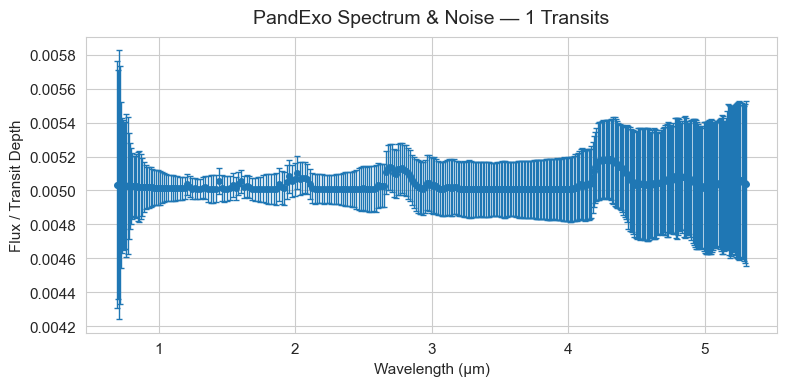

array([7.30712384e-04, 6.75766561e-04, 7.93531282e-04, 7.01703760e-04,
       4.90641106e-04, 3.99089072e-04, 3.82489967e-04, 3.75729423e-04,
       3.76316931e-04, 4.20132128e-04, 4.03325057e-04, 3.12289199e-04,
       2.55822499e-04, 2.22080605e-04, 1.93139986e-04, 1.77578129e-04,
       1.78418394e-04, 1.88780945e-04, 2.05955632e-04, 2.10548317e-04,
       1.92893712e-04, 1.69906130e-04, 1.46966475e-04, 1.28489769e-04,
       1.21141432e-04, 1.22307426e-04, 1.18158290e-04, 1.09288332e-04,
       1.04397569e-04, 1.02981215e-04, 1.02538167e-04, 9.89947520e-05,
       9.19888861e-05, 8.53863256e-05, 8.06350816e-05, 7.76111263e-05,
       7.63594351e-05, 7.53877702e-05, 7.26617782e-05, 6.98513896e-05,
       6.79817257e-05, 6.64680472e-05, 6.48786952e-05, 6.32712677e-05,
       6.21458954e-05, 6.13472608e-05, 6.00326110e-05, 5.89508025e-05,
       5.93284955e-05, 6.27473673e-05, 6.96841621e-05, 7.77818565e-05,
       8.38165960e-05, 8.35740712e-05, 7.95068501e-05, 7.71697886e-05,
      

In [29]:
errors = get_pandexo_noise_from_file("pandexo_spec.txt", n_transits=1, plot=True)

errors

Save Observation Spectrum to use in POSEIDON


Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit


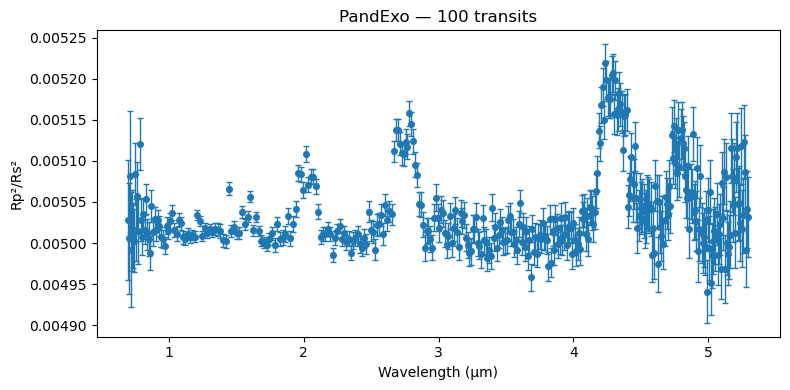

In [ ]:
""" ## Save SPECTRUM

import os
import numpy as np
import pandexo.engine.justdoit as jdi
import matplotlib.pyplot as plt

def save_pandexo_spectrum_to_dat(file_path, n_transits, output_dat, plot=False):
    """
    Corre PandExo y guarda en `output_dat` un archivo con columnas:
    wavelength (μm), wavelength_err (μm), spectrum_w_rand, error_w_floor.
    """
    # --- 1) Configurar PandExo ---
    exo = jdi.load_exo_dict()
    exo["observation"].update({
        "sat_level": 80,
        "sat_unit": "%",
        "baseline_unit": "total",
        "baseline": 0.9535 * 3 * 60 * 60,
        "noise_floor": 0,
        "noccultations": n_transits,
    })
    exo["star"].update({
        "type": "phoenix", "mag": 11.354, "ref_wave": 1.25,
        "temp": 2566, "metal": 0.0, "logg": 5.2396,
    })
    exo["planet"].update({
        "type": "user", "w_unit": "um", "f_unit": "rp^2/r*^2",
        "transit_duration": 0.9535 * 60 * 60, "td_unit": "s",
        "exopath": file_path,
    })
    inst = jdi.load_mode_dict("NIRSpec Prism")
    inst["configuration"]["detector"].update({
        "subarray": "sub512", "ngroup": 6
    })

    # --- 2) Ejecutar PandExo ---
    results = jdi.run_pandexo(exo, inst)  # :contentReference[oaicite:3]{index=3}
    fs = results["FinalSpectrum"]
    
    # --- 3) Recortar primeros 18 puntos ---
    waves_trim    = fs["wave"][18:]
    spec_rand_trim = fs["spectrum_w_rand"][18:]
    err_trim      = fs["error_w_floor"][18:]

    # --- 4) Calcular error en longitud de onda (aprox.) ---
    wave_err = np.gradient(waves_trim) / 2

    # --- 5) Guardar en .dat ---
    data_out = np.vstack([
        waves_trim,
        wave_err,
        spec_rand_trim,
        err_trim
    ]).T
    header = "wavelength(um)  wavelength_err(um)  spectrum_w_rand  error_w_floor"
    np.savetxt(output_dat, data_out, header=header, fmt="%.6e")

    # --- 6) Opcional: plotear ---
    if plot:
        plt.figure(figsize=(8,4))
        plt.errorbar(waves_trim, spec_rand_trim, 
                     xerr=wave_err, yerr=err_trim,
                     fmt='o', ms=4, elinewidth=1, capsize=2)
        plt.xlabel("Wavelength (μm)")
        plt.ylabel("Rp²/Rs²")
        plt.title(f"PandExo — {n_transits} transits")
        plt.tight_layout()
        plt.show()


save_pandexo_spectrum_to_dat(
    "pandexo_spec.txt", 
    n_transits=100, 
    output_dat="pandexo_output_100transits.dat", 
    plot=True
)
 """

## Evaluación del chi cuadrado reducido

In [12]:
# -*- coding: utf-8 -*-
# === UQ para Autoencoder (AE) — Implementación comentada ===
#
# Este módulo implementa dos fuentes de incertidumbre en reconstrucciones con un AE:
#   1) Incertidumbre ALEATORIA (σ_ale): Monte Carlo (MC) perturbando el input ruidoso,
#      normalizando cada réplica por su propio min/max (per-réplica) y DES-normalizando
#      con el rango REAL del espectro limpio (“anchor clean”).
#   2) Incertidumbre EPISTÉMICA (σ_epi): MC Dropout (t pasadas con dropout activo),
#      normalizando respecto al input ruidoso pero DES-normalizando con min/max del limpio.
#
# Además incluye utilidades para combinar incertidumbres y métricas de cobertura.

from __future__ import annotations

from typing import Optional, Tuple, Dict
import numpy as np
import pandas as pd

# Umbral para decidir si una fila (espectro) es “plana” (rango ~ 0).
# Notas:
# - Usamos un epsilon pequeño: si max - min <= EPS_RANGE, consideramos rango ~ 0.
EPS_RANGE = 1e-12


# ---------------------------------------------------------------------------
# 1) INCERTIDUMBRE ALEATORIA (MC de ruido de entrada) — Anchor CLEAN
# ---------------------------------------------------------------------------
def mc_reconstruct_mean_std_full_anchor_clean(
    autoencoder,
    x_noisy_raw: pd.DataFrame,
    x_clean_raw: pd.DataFrame,
    sigma: np.ndarray | float,
    n_repeat: int = 100,
    rng: Optional[np.random.Generator] = None,
    dtype=np.float32,
    forward_chunk: int = 100_000,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Ejecuta Monte Carlo de entrada añadiendo ruido al espectro ruidoso y pasando cada réplica por el AE.

    Normalización y anclaje:
      - Cada réplica se NORMALIZA con su propio min/max (per-réplica), evitando saturar el AE.
      - La DES-normalización de la salida se hace con min/max del espectro LIMPIO (anchor CLEAN).

    Parámetros
    ----------
    autoencoder : Callable
        Modelo AE que acepta array (RN, D) y retorna (RN, D). Debe soportar `training=False`.
    x_noisy_raw : pd.DataFrame, shape (N, D)
        Espectros ruidosos (fila = un espectro). Se usa para generar las réplicas.
    x_clean_raw : pd.DataFrame, shape (N, D)
        Espectros limpios correspondientes (mismo orden y shape que x_noisy_raw).
        Proveen min/max reales para des-normalizar (“anclaje limpio”).
    sigma : float o np.ndarray shape (D,)
        Desv. estándar del ruido a inyectar en cada punto espectral.
        - Escalar: mismo sigma para todos los puntos.
        - Vector (D,): sigma por longitud de onda.
    n_repeat : int
        Número de réplicas MC por espectro.
    rng : np.random.Generator | None
        Generador de números aleatorios. Si es None, se crea uno por defecto.
    dtype : np.dtype
        Tipo numérico a usar (float32 por defecto).
    forward_chunk : int
        Tamaño de lote al inferir para evitar picos de memoria (divide RN en trozos).

    Retorna
    -------
    recon_mean : np.ndarray, shape (N, D)
        Media de las reconstrucciones MC (des-normalizadas al rango del limpio).
    recon_std : np.ndarray, shape (N, D)
        Desviación estándar (ddof=1) de las reconstrucciones MC (σ_ale).

    Notas NumPy/Python (cosas “raras” explicadas)
    ---------------------------------------------
    - `keepdims=True`: conserva dimensión al hacer min/max por filas (N,1), facilitando broadcasting.
    - Broadcasting: cuando multiplicamos (RN, D) por (N,1) indexado con row_idx, NumPy “expande”
      dimensiones compatibles sin copiar datos explícitamente.
    - `reshape(n_repeat * N, D)`: colapsa ejes (T,N,D) a (RN,D) para pasar todo por el AE de una.
    - `ddof=1` en std: usa desviación muestral (corrige sesgo; “delta degrees of freedom”).
    """
    # RNG por defecto si no se provee
    if rng is None:
        rng = np.random.default_rng()

    # Convertimos DataFrame -> ndarray (aseguramos dtype)
    x_noisy = np.asarray(x_noisy_raw.values, dtype=dtype)
    x_clean = np.asarray(x_clean_raw.values, dtype=dtype)
    N, D = x_noisy.shape

    # Validación: los shapes deben coincidir
    if x_clean.shape != (N, D):
        raise ValueError("x_clean_raw must match x_noisy_raw shape.")

    # Estadísticos del LIMPIO (anclaje de des-normalización)
    cmin = x_clean.min(axis=1, keepdims=True).astype(dtype)  # (N,1)
    cmax = x_clean.max(axis=1, keepdims=True).astype(dtype)  # (N,1)
    crng = (cmax - cmin).astype(dtype)                       # (N,1)
    deg_clean = (crng[:, 0] <= EPS_RANGE)                    # espectros planos

    # Construcción de ruido:
    # - si sigma es escalar: ruido ~ N(0, sigma) global
    # - si sigma es vector (D,): ruido por longitud de onda
    if np.ndim(sigma) == 0:
        noise = rng.standard_normal(size=(n_repeat, N, D), dtype=dtype) * float(sigma)
    else:
        sigma_vec = np.asarray(sigma, dtype=dtype)
        if sigma_vec.shape != (D,):
            raise ValueError("sigma must be scalar or have shape (D,)")
        noise = rng.standard_normal(size=(n_repeat, N, D), dtype=dtype) * sigma_vec[None, None, :]

    # Réplicas MC: sumamos ruido al ruidoso
    reps = x_noisy[None, :, :] + noise
    del noise  # liberamos memoria

    # Aplanamos (T, N, D) -> (RN, D), y un índice de fila original por réplica
    reps_2d = reps.reshape(n_repeat * N, D)
    row_idx = np.tile(np.arange(N, dtype=int), n_repeat)  # (RN,)

    # Normalización per-réplica (cada fila de reps_2d)
    reps_min = reps_2d.min(axis=1, keepdims=True).astype(dtype)  # (RN,1)
    reps_max = reps_2d.max(axis=1, keepdims=True).astype(dtype)  # (RN,1)
    reps_rng = (reps_max - reps_min).astype(dtype)               # (RN,1)

    # Evitar división por 0: si rango <= 0, sustitúyelo por 1.0 (np.where evita warnings)
    reps_rng_safe = np.where(reps_rng <= 0.0, 1.0, reps_rng).astype(dtype)

    # Normalizamos a [0,1]
    reps_norm = (reps_2d - reps_min) / reps_rng_safe

    # Marcar réplicas degeneradas (rango ~ 0): si lo son, fijamos la fila a 0.0 tras normalizar
    deg_reps = (reps_rng[:, 0] <= EPS_RANGE)
    if np.any(deg_reps):
        reps_norm[deg_reps] = 0.0

    # Inferencia por chunks para no reventar memoria
    RN = reps_norm.shape[0]
    preds_norm = np.empty_like(reps_norm, dtype=dtype)
    for i in range(0, RN, forward_chunk):
        j = min(i + forward_chunk, RN)
        # Importante: training=False (inferencia sin dropout/BN en modo entrenamiento)
        preds_norm[i:j] = autoencoder(reps_norm[i:j], training=False).numpy().astype(dtype, copy=False)

    # Des-normalizamos usando el rango del LIMPIO (anclaje clean) por fila original
    preds_denorm = preds_norm * crng[row_idx] + cmin[row_idx]

    # Si el limpio era plano, forzamos constante (= cmin)
    if np.any(deg_clean):
        rep_deg = np.repeat(deg_clean, n_repeat)  # (RN,) mapea filas por réplica
        preds_denorm[rep_deg] = cmin[row_idx][rep_deg]

    # Reponemos ejes (T, N, D) para estadísticos MC
    preds_denorm = preds_denorm.reshape(n_repeat, N, D)
    recon_mean = preds_denorm.mean(axis=0)
    # ddof=1 → desviación muestral
    recon_std = preds_denorm.std(axis=0, ddof=1)

    # Limpieza
    del reps, reps_2d, reps_min, reps_max, reps_rng, reps_rng_safe, deg_reps
    del reps_norm, preds_norm, preds_denorm, row_idx, cmin, cmax, crng

    return recon_mean, recon_std


# ---------------------------------------------------------------------------
# 2) INCERTIDUMBRE EPISTÉMICA (MC Dropout) — Anchor CLEAN (CORREGIDA)
# ---------------------------------------------------------------------------
def mc_dropout_sigma_anchor_clean(
    autoencoder,
    x_noisy_raw: pd.DataFrame,
    x_clean_raw: pd.DataFrame,      # se usa SOLO para DES-normalizar correctamente
    t_passes: int = 100,
    dtype=np.float32,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Estima incertidumbre epistémica con MC Dropout: ejecuta T pasadas con `training=True`.

    Flujo:
      1) Normaliza el input ruidoso por fila (min/max del ruidoso) → x_norm ∈ [0,1].
      2) Realiza T inferencias con dropout activo (training=True).
      3) DES-normaliza cada salida usando min/max del LIMPIO (anclaje clean).
      4) Promedia (media) y calcula std (ddof=1) a través de T → σ_epi.

    Parámetros
    ----------
    autoencoder : Callable
        Modelo AE que soporte `training=True` (activa dropout).
    x_noisy_raw : pd.DataFrame, shape (N, D)
        Espectros ruidosos (para normalización de entrada).
    x_clean_raw : pd.DataFrame, shape (N, D)
        Espectros limpios (para des-normalizar salidas con min/max reales).
    t_passes : int
        Número de pasadas con dropout activo.
    dtype : np.dtype
        Tipo numérico.

    Retorna
    -------
    mean_dropout : np.ndarray, shape (N, D)
        Media de las T salidas des-normalizadas.
    sigma_epi : np.ndarray, shape (N, D)
        Desviación estándar (ddof=1) entre las T salidas (incertidumbre epistémica).
    """
    # --- 1) Normalización basada en el RUIDOSO (por fila) ---
    x_noisy = np.asarray(x_noisy_raw.values, dtype=dtype)
    N, D = x_noisy.shape
    x_min = x_noisy.min(axis=1, keepdims=True).astype(dtype)  # (N,1)
    x_max = x_noisy.max(axis=1, keepdims=True).astype(dtype)  # (N,1)
    x_rng = (x_max - x_min).astype(dtype)                      # (N,1)

    # `np.where` evita división por 0: si rango <= 0 → usa 1.0
    x_rng_safe = np.where(x_rng <= 0.0, 1.0, x_rng).astype(dtype)
    deg_noisy = (x_rng[:, 0] <= EPS_RANGE)

    x_norm = (x_noisy - x_min) / x_rng_safe
    if np.any(deg_noisy):
        x_norm[deg_noisy] = 0.0  # filas planas → vector de ceros

    # --- 2) Estadísticos del LIMPIO para DES-normalizar salidas ---
    x_clean = np.asarray(x_clean_raw.values, dtype=dtype)
    if x_clean.shape != (N, D):
        raise ValueError("x_clean_raw must match x_noisy_raw shape.")

    c_min = x_clean.min(axis=1, keepdims=True).astype(dtype)  # (N,1)
    c_max = x_clean.max(axis=1, keepdims=True).astype(dtype)  # (N,1)
    c_rng = (c_max - c_min).astype(dtype)                      # (N,1)
    deg_clean = (c_rng[:, 0] <= EPS_RANGE)

    # --- 3) T pasadas con dropout ACTIVO (training=True) ---
    outs_norm = []
    for _ in range(int(t_passes)):
        # NOTA: training=True activa dropout (y BatchNorm en modo train si existiera).
        y = autoencoder(x_norm, training=True).numpy().astype(dtype, copy=False)
        outs_norm.append(y)
    outs_norm = np.stack(outs_norm, axis=0)  # (T, N, D)

    # --- 4) DES-normalizar con min/max del LIMPIO (anclaje clean) ---
    # Broadcasting: (T,N,D) * (N,1) → (T,N,D)
    outs = outs_norm * c_rng[None, :, :] + c_min[None, :, :]
    if np.any(deg_clean):
        # Filas planas en limpio → salida constante (c_min)
        outs[:, deg_clean, :] = c_min[deg_clean]
    del outs_norm

    # --- 5) Estadísticos en el eje T (pasadas MC) ---
    mean_dropout = outs.mean(axis=0).astype(dtype)                # (N,D)
    sigma_epi = outs.std(axis=0, ddof=1).astype(dtype)            # (N,D)
    del outs

    return mean_dropout, sigma_epi


# ---------------------------------------------------------------------------
# 3) COMBINACIÓN DE INCERTIDUMBRES Y MÉTRICAS
# ---------------------------------------------------------------------------
def combine_uncertainties(
    sigma_ale: np.ndarray,
    sigma_epi: Optional[np.ndarray] = None,
    sigma_sys: Optional[np.ndarray] = None,
    floor: float = 0.0,
    dtype=np.float32,
) -> np.ndarray:
    """
    Combina incertidumbres independientes en cuadratura: σ_total = sqrt(σ_ale² + σ_epi² + σ_sys²).

    Parámetros
    ----------
    sigma_ale : np.ndarray, shape (N, D)
        Incertidumbre aleatoria.
    sigma_epi : np.ndarray | None, shape (N, D)
        Incertidumbre epistémica (opcional).
    sigma_sys : np.ndarray | None, shape (N, D) o (D,)
        Piso/sesgo sistemático (opcional).
    floor : float
        Piso mínimo absoluto para σ_total (útil para evitar ceros).
    dtype : np.dtype
        Tipo numérico de salida.

    Retorna
    -------
    sigma_total : np.ndarray, shape (N, D)
        Incertidumbre total.

    Notas:
    - Uso de `np.asarray(..., dtype)**2`: convierte y eleva al cuadrado en un paso.
    - `np.maximum(sigma_total, floor)`: impone un piso de error si se desea.
    """
    sig2 = np.asarray(sigma_ale, dtype=dtype) ** 2
    if sigma_epi is not None:
        sig2 += np.asarray(sigma_epi, dtype=dtype) ** 2
    if sigma_sys is not None:
        sig2 += np.asarray(sigma_sys, dtype=dtype) ** 2
    sigma_total = np.sqrt(sig2, dtype=dtype)
    if floor > 0.0:
        sigma_total = np.maximum(sigma_total, floor).astype(dtype, copy=False)
    return sigma_total


def coverage_metrics(y_true: np.ndarray, y_pred: np.ndarray, sigma: np.ndarray) -> Dict[str, float]:
    """
    Calcula “coverage” empírico asumiendo normalidad (z-score = (y_true - y_pred)/sigma):
      - coverage_1sigma = P(|z| <= 1)
      - coverage_2sigma = P(|z| <= 2)

    Notas:
    - Reemplazamos sigma <= 0 por `eps` para evitar división por cero.
    - No devuelve p-values; es una métrica descriptiva de calibración.

    Retorna
    -------
    dict con coverage_1sigma y coverage_2sigma.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    sigma = np.asarray(sigma)

    # Si algún sigma ≤ 0, lo sustituimos por el epsilon del dtype (mínimo positivo representable)
    sigma = np.where(sigma <= 0.0, np.finfo(sigma.dtype).eps, sigma)

    z = (y_true - y_pred) / sigma
    z_abs = np.abs(z)
    return {
        "coverage_1sigma": float(np.mean(z_abs <= 1.0)),
        "coverage_2sigma": float(np.mean(z_abs <= 2.0)),
    }


def sigma_comparison_summary(
    sigma_inst: np.ndarray,   # instrumental o de referencia
    sigma_ale: np.ndarray,
    sigma_epi: np.ndarray,
    sigma_total: np.ndarray,
) -> Dict[str, float]:
    """
    Resumen de ratios y correlaciones entre diferentes σ respecto a una referencia (p.ej., instrumental).

    Métricas:
      - Medianas de (σ_x / σ_inst) para x ∈ {ale, epi, total}
      - Correlaciones de Pearson entre σ_x y σ_inst

    Cosas “raras” explicadas:
      - `_flat(a)`: convierte a 1D con `ravel()` y filtra no finitos. `ravel()` evita copias si puede.
      - `np.clip(b, 1e-12, np.inf)`: evita divisiones por ~0.
      - Correlación: `np.corrcoef(a, b)[0,1]` retorna matriz 2x2; tomamos el off-diagonal.

    Retorna
    -------
    dict con median ratios y correlaciones.
    """
    N, D = sigma_ale.shape

    # Si sigma_inst es (D,), hacemos broadcasting a (N,D) para comparar por fila
    sigma_inst2 = (
        np.broadcast_to(sigma_inst[None, :], (N, D))
        if sigma_inst.ndim == 1 else sigma_inst
    )

    def _flat(a):
        a = np.asarray(a, dtype=np.float64).ravel()  # ravel: vista 1D si es posible (evita copia)
        return a[np.isfinite(a)]                     # filtramos NaN/inf para métricas robustas

    def _med_ratio(a, b):
        a1, b1 = _flat(a), _flat(b)
        m = min(a1.size, b1.size)
        if m == 0:
            return np.nan
        return float(np.median(a1[:m] / np.clip(b1[:m], 1e-12, np.inf)))

    def _corr(a, b):
        a1, b1 = _flat(a), _flat(b)
        m = min(a1.size, b1.size)
        if m < 2:
            return np.nan
        return float(np.corrcoef(a1[:m], b1[:m])[0, 1])

    return {
        "med_ratio_ale_vs_inst": _med_ratio(sigma_ale, sigma_inst2),
        "med_ratio_epi_vs_inst": _med_ratio(sigma_epi, sigma_inst2),
        "med_ratio_tot_vs_inst": _med_ratio(sigma_total, sigma_inst2),
        "corr_ale_vs_inst": _corr(sigma_ale, sigma_inst2),
        "corr_epi_vs_inst": _corr(sigma_epi, sigma_inst2),
        "corr_tot_vs_inst": _corr(sigma_total, sigma_inst2),
    }


In [13]:

# === Cell 2 (corregida) ===
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd

# ---------------- Parámetros ----------------
N_TRANSITS = 10
MONTE_CARLO_REPEATS = 300
T_PASSES_DROPOUT = 100
EPS_SIGMA = 1e-12
LATENT_DIM = 300
factor = 10 / 8

# -------------- Ruido instrumental -----------
errors = get_pandexo_noise_from_file("pandexo_spec.txt", n_transits=N_TRANSITS, plot=False)
errors = errors[::-1]
noise = errors  # alias

# -------------- Construcción de datasets -----
n_co2 = int(2500)
n_ch4 = int(250 * factor)
n_o3  = int(250 * factor)
n_h2o = int(250 * factor)
n_ch4_o3 = int(25 * factor * factor)
n_ch4_h2o = int(25 * factor * factor)
n_o3_h2o  = int(25 * factor * factor)
n_ch4_o3_h2o = int(2 * factor * factor * factor)
n_airless = int(100 * 3)

df_noisy = pd.concat(
    [
        #generate_df_with_noise_std(O3_H2O_data, n_o3_h2o, noise),
        #generate_df_with_noise_std(CH4_H2O_data, n_ch4_h2o, noise),
        #generate_df_with_noise_std(CH4_O3_data, n_ch4_o3, noise),
        #generate_df_with_noise_std(H2O_data, n_h2o, noise),
        #generate_df_with_noise_std(O3_data, n_o3, noise),
        #generate_df_with_noise_std(CH4_data, n_ch4, noise),
        #generate_df_with_noise_std(CO2_data, n_co2, noise),
        generate_df_with_noise_std(CH4_O3_H2O_data, n_ch4_o3_h2o, noise),
        generate_df_with_noise_std(airless_data, n_airless, noise),
    ], ignore_index=True,
)
df_clean = pd.concat(
    [
        #generate_df_with_noise_std(O3_H2O_data_clean, n_o3_h2o, 0),
        #generate_df_with_noise_std(CH4_H2O_data_clean, n_ch4_h2o, 0),
        #generate_df_with_noise_std(CH4_O3_data_clean, n_ch4_o3, 0),
        #generate_df_with_noise_std(H2O_data_clean, n_h2o, 0),
        #generate_df_with_noise_std(O3_data_clean, n_o3, 0),
        #generate_df_with_noise_std(CH4_data_clean, n_ch4, 0),
        #generate_df_with_noise_std(CO2_data_clean, n_co2, 0),
        generate_df_with_noise_std(CH4_O3_H2O_data_clean, n_ch4_o3_h2o, 0),
        generate_df_with_noise_std(airless_data_clean, n_airless, 0),
    ], ignore_index=True,
)

# -------------- Señales (últimas n_points columnas) --------------
X_noisy_raw = df_noisy.iloc[:, -n_points:]
X_clean_raw = df_clean.iloc[:, -n_points:]

# -------------- Recon + Sigmas --------------
_, sigma_ale = mc_reconstruct_mean_std_full_anchor_clean(
    autoencoder=autoencoder,
    x_noisy_raw=X_noisy_raw,
    x_clean_raw=X_clean_raw,
    sigma=errors,                     # escalar o (D,)
    n_repeat=MONTE_CARLO_REPEATS,
    dtype=np.float32,
    forward_chunk=100_000,            # baja si hay OOM
)
mean_dropout, sigma_epi = mc_dropout_sigma_anchor_clean(
    autoencoder=autoencoder,
    x_noisy_raw=X_noisy_raw,
    x_clean_raw=X_clean_raw, # <-- Se añade el DataFrame limpio
    t_passes=T_PASSES_DROPOUT,
    dtype=np.float32,
)


recon_mean = mean_dropout
sigma_total = combine_uncertainties(sigma_ale=sigma_ale, sigma_epi=sigma_epi, floor=EPS_SIGMA, dtype=np.float32)

# -------------- Guardado --------------
np.savez("dae_uq_outputs.npz",
         recon_mean=recon_mean, sigma_ale=sigma_ale, sigma_epi=sigma_epi, sigma_total=sigma_total)
print(">>> Saved: dae_uq_outputs.npz")

# -------------- χ² consistentes (si tienes helpers chi2/chi2_r) ----
try:
    # (A) Obs vs Recon con σ_inst (explicar observación)
    chi2_obs     = chi2(X_noisy_raw.values, recon_mean, errors)
    chi2r_obs_p0 = chi2_r(X_noisy_raw.values, recon_mean, errors, p=0)
    # (B) Clean vs Recon con σ_total (chequeo predictivo del limpio)
    sigT = np.clip(sigma_total, EPS_SIGMA, np.inf)
    chi2_clean_tot     = chi2(X_clean_raw.values, recon_mean, sigT)
    chi2r_clean_tot_p0 = chi2_r(X_clean_raw.values, recon_mean, sigT, p=0)

    print(f">>> Results for {N_TRANSITS} transits <<<")
    print("== Obs - Recon con σ_inst ==")
    print(f"mean χ²_r (p=0): {np.mean(chi2r_obs_p0):.4f}")
    print("\n== Clean - Recon con σ_total ==")
    print(f"mean χ²_r (p=0): {np.mean(chi2r_clean_tot_p0):.4f}")
except NameError:
    print("Aviso: chi2/chi2_r no están definidas; omite esta sección o impórtalas.")

# -------------- Comparación + Coverage ----------------------------
cmp_stats = sigma_comparison_summary(
    sigma_inst=errors, sigma_ale=sigma_ale, sigma_epi=sigma_epi, sigma_total=sigma_total
)
print("\n== Sigma comparison ==")
for k, v in cmp_stats.items():
    print(f"{k:>22}: {v:.4f}")

cov_obs = coverage_metrics(X_noisy_raw.values, recon_mean, errors)
cov_tot = coverage_metrics(X_clean_raw.values, recon_mean, np.clip(sigma_total, EPS_SIGMA, np.inf))
print("\n== Coverage ==")
print(f"Obs-Rec c/ σ_inst : 68%={cov_obs['coverage_1sigma']:.3f}  95%={cov_obs['coverage_2sigma']:.3f}")
print(f"Clean-Rec c/ σ_tot: 68%={cov_tot['coverage_1sigma']:.3f}  95%={cov_tot['coverage_2sigma']:.3f}")

Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation


        Use "format" instead. [pandeia.engine.extinction]
c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:


End out of Transit
Starting In Transit Simulation
End In Transit
Using per-wavelength noise_std vector
Using per-wavelength noise_std vector
Using scalar noise_std = 0
Using scalar noise_std = 0
>>> Saved: dae_uq_outputs.npz
>>> Results for 10 transits <<<
== Obs - Recon con σ_inst ==
mean χ²_r (p=0): 45.0944

== Clean - Recon con σ_total ==
mean χ²_r (p=0): 0.7432

== Sigma comparison ==
 med_ratio_ale_vs_inst: 0.2900
 med_ratio_epi_vs_inst: 0.1227
 med_ratio_tot_vs_inst: 0.3277
      corr_ale_vs_inst: 0.1267
      corr_epi_vs_inst: 0.0098
      corr_tot_vs_inst: 0.1116

== Coverage ==
Obs-Rec c/ σ_inst : 68%=0.230  95%=0.398
Clean-Rec c/ σ_tot: 68%=0.899  95%=0.975


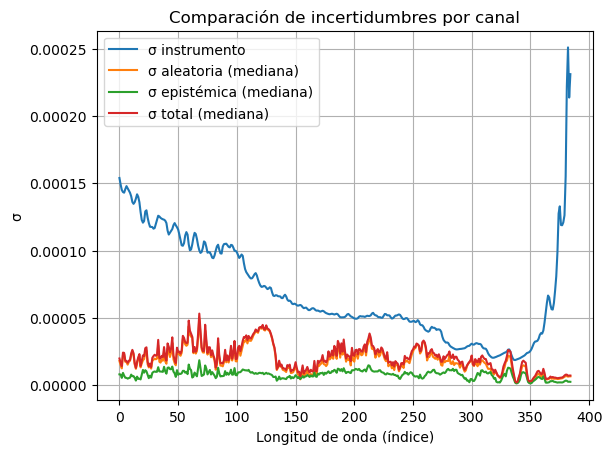

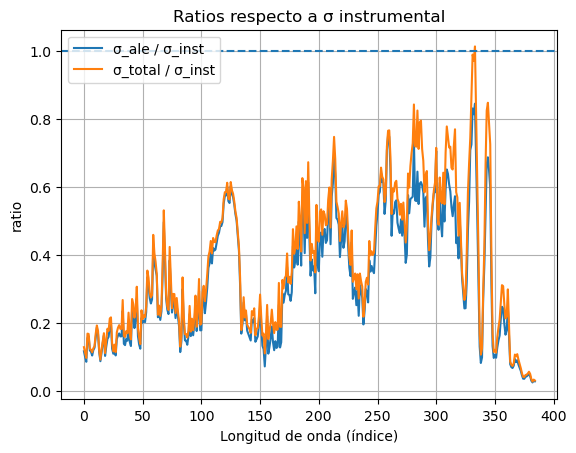


== Coverage (fracción de puntos) ==
Instrumental:  68%=0.988  95%=0.999
Aleatoria:     68%=0.859  95%=0.958
Total (A+E):   68%=0.899  95%=0.975


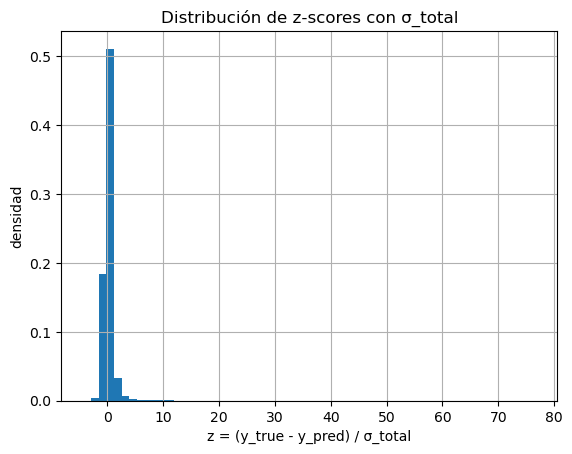


Guardado: C:\Proyectos\Astro\AEspectra\exp 0\sigma_summary.csv


In [14]:
# === Plots & resumen de incertidumbres ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def _as_ndarray(x):
    if isinstance(x, (pd.DataFrame, pd.Series)):
        return x.values
    return np.asarray(x)

def _broadcast_sigma_inst(sigma_inst, N, D):
    s = _as_ndarray(sigma_inst)
    if s.ndim == 1:
        if s.shape[0] != D:
            raise ValueError(f"len(sigma_inst)={s.shape[0]} != D={D}")
        sD = s
        sND = np.broadcast_to(s[None, :], (N, D))
    elif s.ndim == 2:
        if s.shape != (N, D):
            raise ValueError(f"sigma_inst shape {s.shape} ≠ (N,D)=({N},{D})")
        sND = s
        sD = s.mean(axis=0)
    else:
        raise ValueError("sigma_inst debe ser (D,) o (N,D)")
    return sD, sND

def _coverage(y_true, y_pred, sigma):
    y_true = _as_ndarray(y_true)
    y_pred = _as_ndarray(y_pred)
    sigma  = _as_ndarray(sigma)
    sigma  = np.where(sigma <= 0, np.finfo(float).eps, sigma)
    z = (y_true - y_pred) / sigma
    z = z[np.isfinite(z)]
    if z.size == 0:
        return np.nan, np.nan, z
    cov1 = float(np.mean(np.abs(z) <= 1.0))
    cov2 = float(np.mean(np.abs(z) <= 2.0))
    return cov1, cov2, z

# ----------- Recolecta variables del entorno -----------
sigma_ale   = _as_ndarray(sigma_ale)         # (N,D)
sigma_epi   = _as_ndarray(sigma_epi)         # (N,D)
sigma_total = _as_ndarray(sigma_total)       # (N,D)
N, D = sigma_ale.shape

sigma_inst_var = errors if 'errors' in globals() else noise   # (D,) o (N,D)
sigma_inst_D, sigma_inst_ND = _broadcast_sigma_inst(sigma_inst_var, N, D)

wl = _as_ndarray(wavelengths) if 'wavelengths' in globals() else np.arange(D)
if wl.shape[0] != D: wl = np.arange(D)

# ----------- Resúmenes por longitud de onda -----------
sigma_ale_med = np.median(sigma_ale, axis=0)
sigma_epi_med = np.median(sigma_epi, axis=0)
sigma_tot_med = np.median(sigma_total, axis=0)
eps = 1e-12
ratio_ale_inst = sigma_ale_med / np.clip(sigma_inst_D, eps, None)
ratio_tot_inst = sigma_tot_med / np.clip(sigma_inst_D, eps, None)

# ----------- Plot 1: σ por canal -----------
plt.figure()
plt.plot(wl, sigma_inst_D, label="σ instrumento")
plt.plot(wl, sigma_ale_med, label="σ aleatoria (mediana)")
plt.plot(wl, sigma_epi_med, label="σ epistémica (mediana)")
plt.plot(wl, sigma_tot_med, label="σ total (mediana)")
plt.xlabel("Longitud de onda" if wl.ndim==1 and wl.dtype!=int else "Longitud de onda (índice)")
plt.ylabel("σ")
plt.title("Comparación de incertidumbres por canal")
plt.legend()
plt.grid(True)
plt.show()

# ----------- Plot 2: Ratios vs instrumento -----------
plt.figure()
plt.plot(wl, ratio_ale_inst, label="σ_ale / σ_inst")
plt.plot(wl, ratio_tot_inst, label="σ_total / σ_inst")
plt.axhline(1.0, linestyle="--")
plt.xlabel("Longitud de onda" if wl.ndim==1 and wl.dtype!=int else "Longitud de onda (índice)")
plt.ylabel("ratio")
plt.title("Ratios respecto a σ instrumentaI")
plt.legend()
plt.grid(True)
plt.show()

# ----------- Coverage + histograma de z (si hay y_true/y_pred) ------
if 'recon_mean' in globals() and 'X_clean_raw' in globals():
    y_pred = _as_ndarray(recon_mean)          # (N,D)
    y_true = _as_ndarray(X_clean_raw)         # (N,D)
    cov1_i, cov2_i, z_i = _coverage(y_true, y_pred, sigma_inst_ND)
    cov1_a, cov2_a, z_a = _coverage(y_true, y_pred, sigma_ale)
    cov1_t, cov2_t, z_t = _coverage(y_true, y_pred, sigma_total)

    print("\n== Coverage (fracción de puntos) ==")
    print(f"Instrumental:  68%={cov1_i:.3f}  95%={cov2_i:.3f}")
    print(f"Aleatoria:     68%={cov1_a:.3f}  95%={cov2_a:.3f}")
    print(f"Total (A+E):   68%={cov1_t:.3f}  95%={cov2_t:.3f}")

    plt.figure()
    plt.hist(z_t, bins=60, density=True)
    plt.xlabel("z = (y_true - y_pred) / σ_total")
    plt.ylabel("densidad")
    plt.title("Distribución de z-scores con σ_total")
    plt.grid(True)
    plt.show()

# ----------- CSV resumen por longitud de onda -----------
summary = pd.DataFrame({
    "lambda": wl if wl.ndim == 1 else np.arange(D),
    "sigma_inst": sigma_inst_D,
    "sigma_ale_med": sigma_ale_med,
    "sigma_epi_med": sigma_epi_med,
    "sigma_total_med": sigma_tot_med,
    "ratio_ale_inst": ratio_ale_inst,
    "ratio_total_inst": ratio_tot_inst,
})
summary_path = Path("sigma_summary.csv")
summary.to_csv(summary_path, index=False)
print(f"\nGuardado: {summary_path.resolve()}")


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["STIXGeneral", "DejaVu Serif", "Times New Roman", "CMU Serif", "Liberation Serif"]
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False

mpl.rcParams["axes.titlesize"]    = 14
mpl.rcParams["axes.titleweight"]  = "normal"
mpl.rcParams["axes.titlepad"]     = 10
mpl.rcParams["figure.titlesize"]  = 16
mpl.rcParams["figure.titleweight"] = "normal"


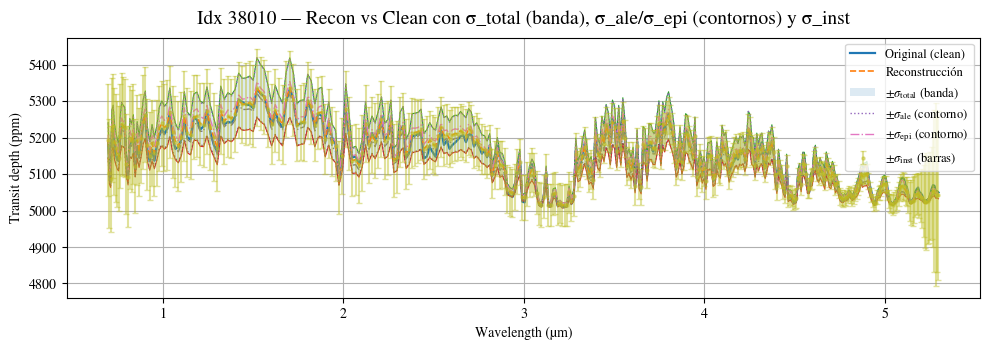

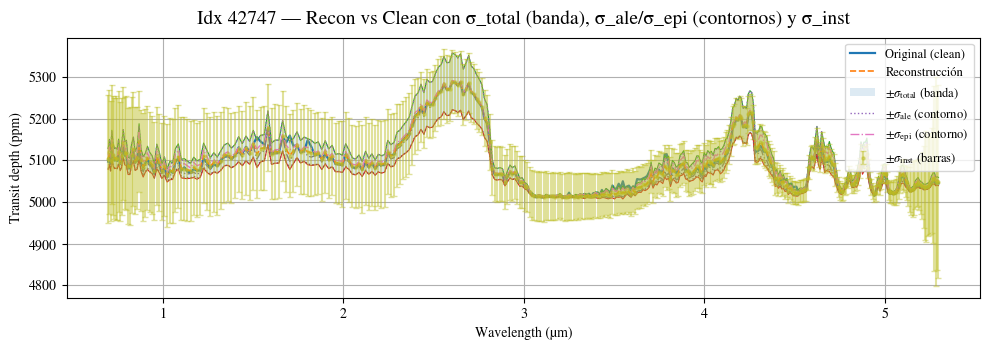

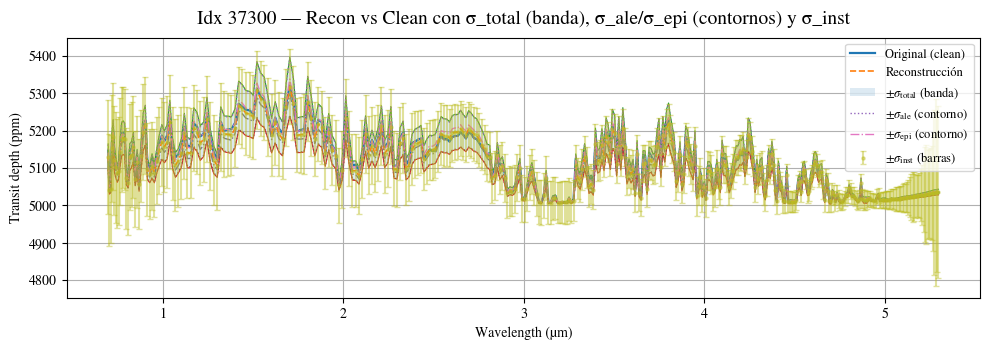

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers ----------
def _as_nd(x):
    import pandas as pd
    if isinstance(x, (pd.DataFrame, pd.Series)): return x.values
    return np.asarray(x)

def _per_sample_sigma(s, i, N, D):
    s = _as_nd(s)
    if s.ndim == 1:
        if s.shape[0] != D: raise ValueError(f"sigma length {s.shape[0]} != D={D}")
        return s
    elif s.ndim == 2:
        if s.shape != (N, D): raise ValueError(f"sigma shape {s.shape} != (N,D)=({N},{D})")
        return s[i]
    raise ValueError("sigma must be (D,) or (N,D)")

# ---------- función principal ----------
def plot_four_sigmas_singlepanel(indices=None, n_random=3, rng_seed=None, ppm=True,
                                 waves_key="wavelengths", show_inst=True,
                                 lw_lines=1.0, lw_edges=0.8, alpha_total=0.15):
    """
    Un panel por espectro:
      - línea clean
      - línea recon
      - banda ±σ_total con borde
      - contornos ±σ_ale y ±σ_epi
      - (opcional) barras ±σ_inst sobre la recon
    """
    # variables requeridas del entorno
    Yc   = _as_nd(X_clean_raw)
    Yr   = _as_nd(recon_mean)
    sig_inst = errors
    sig_ale  = sigma_ale
    sig_epi  = sigma_epi
    sig_tot  = sigma_total

    N, D = Yr.shape

    # eje x
    if waves_key in globals():
        wl = _as_nd(globals()[waves_key])
    elif "waves" in globals():
        wl = _as_nd(globals()["waves"])
    else:
        wl = np.arange(D)
    if wl.shape[0] != D:
        wl = np.arange(D)

    # índices
    rng = np.random.default_rng(rng_seed)
    if indices is None:
        n_random = min(n_random, N)
        idxs = rng.choice(N, size=n_random, replace=False)
    else:
        idxs = np.asarray(indices, dtype=int)

    # escala
    scale = 1e6 if ppm else 1.0
    unit  = "ppm" if ppm else "arb."

    for i in idxs:
        y_clean = Yc[i]
        y_recon = Yr[i]
        s_inst_i = _per_sample_sigma(sig_inst, i, N, D)
        s_ale_i  = _per_sample_sigma(sig_ale,  i, N, D)
        s_epi_i  = _per_sample_sigma(sig_epi,  i, N, D)
        s_tot_i  = _per_sample_sigma(sig_tot,  i, N, D)

        y_clean_p = y_clean * scale
        y_recon_p = y_recon * scale
        s_inst_p  = s_inst_i * scale
        s_ale_p   = s_ale_i  * scale
        s_epi_p   = s_epi_i  * scale
        s_tot_p   = s_tot_i  * scale

        plt.figure(figsize=(10, 3.6))

        # 1) líneas clean & recon
        plt.plot(wl, y_clean_p, lw=1.6, label="Original (clean)")
        plt.plot(wl, y_recon_p, lw=1.2, linestyle="--", label="Reconstrucción")

        # 2) banda ±σ_total con borde
        band = plt.fill_between(wl, y_recon_p - s_tot_p, y_recon_p + s_tot_p,
                                alpha=alpha_total, label=r"±$\sigma_{\rm total}$ (banda)")
        # bordes explícitos de la banda (para que “el shadow tenga borde”)
        plt.plot(wl, y_recon_p + s_tot_p, lw=lw_edges)
        plt.plot(wl, y_recon_p - s_tot_p, lw=lw_edges)

        # 3) contornos ±σ_ale (líneas más finas)
        plt.plot(wl, y_recon_p + s_ale_p, lw=lw_lines, linestyle=":", label=r"±$\sigma_{\rm ale}$ (contorno)")
        plt.plot(wl, y_recon_p - s_ale_p, lw=lw_lines, linestyle=":")

        # 4) contornos ±σ_epi (líneas finas, estilo distinto)
        plt.plot(wl, y_recon_p + s_epi_p, lw=lw_lines, linestyle="-.", label=r"±$\sigma_{\rm epi}$ (contorno)")
        plt.plot(wl, y_recon_p - s_epi_p, lw=lw_lines, linestyle="-.")

        # 5) barras ±σ_inst sobre la recon (referencia de escala)
        if show_inst:
            plt.errorbar(wl, y_recon_p, yerr=s_inst_p, fmt='o', ms=2.2, capsize=2,
                         alpha=0.45, label=r"±$\sigma_{\rm inst}$ (barras)")

        plt.xlabel("Wavelength (µm)" if wl.dtype.kind != 'i' else "Channel index")
        plt.ylabel(f"Transit depth ({unit})")
        plt.title(f"Idx {i} — Recon vs Clean con σ_total (banda), σ_ale/σ_epi (contornos){' y σ_inst' if show_inst else ''}")
        plt.legend(loc="best", fontsize=9, frameon=True)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# ===== Ejemplos =====
# Tres índices aleatorios, mostrando los cuatro sigmas
plot_four_sigmas_singlepanel(n_random=3,  ppm=True)

# Índices fijos
# plot_four_sigmas_singlepanel(indices=[1000, 2000], ppm=True)


In [17]:
df_noisy[df_noisy["atm CO2"] != 0.00]


,noise_std,n_repeat,f_spot,f_fac,Unnamed: 0,sma,seed,p_radius,p_mass,p_seed,...,0.764875,0.756764,0.748855,0.741148,0.733644,0.726317,0.71918,0.712225,0.705435,0.698805
0,NaN,3,0.0,0.0,666,0.02925,NaN,0.92,0.692,NaN,...,0.004993,0.005108,0.004946,0.005294,0.005061,0.005068,0.005448,0.004696,0.004894,0.005100
1,NaN,3,0.0,0.0,666,0.02925,NaN,0.92,0.692,NaN,...,0.004851,0.005176,0.005115,0.004952,0.004909,0.004997,0.005284,0.005117,0.005015,0.005184
2,NaN,3,0.0,0.0,666,0.02925,NaN,0.92,0.692,NaN,...,0.004890,0.005067,0.005130,0.005149,0.005282,0.005370,0.004893,0.004923,0.004829,0.005141
3,NaN,3,0.0,0.0,667,0.02925,NaN,0.92,0.692,NaN,...,0.005029,0.005131,0.004942,0.004830,0.005010,0.004799,0.004846,0.004885,0.005102,0.004893
4,NaN,3,0.0,0.0,667,0.02925,NaN,0.92,0.692,NaN,...,0.004909,0.005118,0.004932,0.005087,0.005053,0.005093,0.005115,0.004792,0.004944,0.005187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46075,NaN,3,0.26,0.7,2998,0.02925,NaN,0.92,0.692,NaN,...,0.003374,0.003946,0.003639,0.003900,0.004910,0.004493,0.003731,0.004381,0.004521,0.004416
46076,NaN,3,0.26,0.7,2998,0.02925,NaN,0.92,0.692,NaN,...,0.003262,0.004111,0.003754,0.003994,0.004858,0.004400,0.004189,0.003831,0.004816,0.004144
46077,NaN,3,0.26,0.7,2999,0.02925,NaN,0.92,0.692,NaN,...,0.003484,0.004028,0.003624,0.003978,0.004978,0.004497,0.004483,0.003573,0.004431,0.004410
46078,NaN,3,0.26,0.7,2999,0.02925,NaN,0.92,0.692,NaN,...,0.003207,0.004151,0.003519,0.003792,0.004877,0.004356,0.004300,0.003581,0.004848,0.004805


In [18]:
df_noisy[
    #(df_noisy["atm CO2"] == 0) &
    (df_noisy["atm CH4"] == -6) &
    (df_noisy["atm O3"] == -5) &
    (df_noisy["atm H2O"] == -5) &
    (df_noisy["f_spot"] == 0) &
    (df_noisy["f_fac"] == 0)
]


,noise_std,n_repeat,f_spot,f_fac,Unnamed: 0,sma,seed,p_radius,p_mass,p_seed,...,0.764875,0.756764,0.748855,0.741148,0.733644,0.726317,0.71918,0.712225,0.705435,0.698805
1395,NaN,3,0.0,0.0,1365,0.02925,NaN,0.92,0.692,NaN,...,0.004974,0.005100,0.005158,0.005124,0.005047,0.004835,0.005174,0.005222,0.004849,0.005102
1396,NaN,3,0.0,0.0,1365,0.02925,NaN,0.92,0.692,NaN,...,0.005100,0.004972,0.005015,0.005056,0.005170,0.005376,0.005322,0.004805,0.005151,0.004983
1397,NaN,3,0.0,0.0,1365,0.02925,NaN,0.92,0.692,NaN,...,0.004996,0.004998,0.005062,0.004959,0.004903,0.005006,0.004720,0.005223,0.004969,0.005228
1398,NaN,3,0.0,0.0,1366,0.02925,NaN,0.92,0.692,NaN,...,0.005158,0.005236,0.004792,0.005058,0.004897,0.005120,0.004889,0.005000,0.004857,0.004777
1399,NaN,3,0.0,0.0,1366,0.02925,NaN,0.92,0.692,NaN,...,0.005126,0.004888,0.004829,0.005003,0.004996,0.005068,0.005159,0.005225,0.005011,0.005049
1400,NaN,3,0.0,0.0,1366,0.02925,NaN,0.92,0.692,NaN,...,0.004902,0.005025,0.005041,0.004896,0.004992,0.005185,0.005465,0.004828,0.004875,0.004789
1401,NaN,3,0.0,0.0,1367,0.02925,NaN,0.92,0.692,NaN,...,0.005185,0.004982,0.005125,0.005155,0.005160,0.005013,0.004991,0.005139,0.004799,0.004820
1402,NaN,3,0.0,0.0,1367,0.02925,NaN,0.92,0.692,NaN,...,0.005132,0.005024,0.005077,0.005033,0.005119,0.005127,0.005299,0.004638,0.005331,0.004888
1403,NaN,3,0.0,0.0,1367,0.02925,NaN,0.92,0.692,NaN,...,0.005146,0.004917,0.004995,0.004984,0.005107,0.005383,0.005819,0.005053,0.004828,0.004938


In [19]:
 len(waves[::-1])

385

C:\Users\User\AppData\Local\Temp\ipykernel_18572\1382471491.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


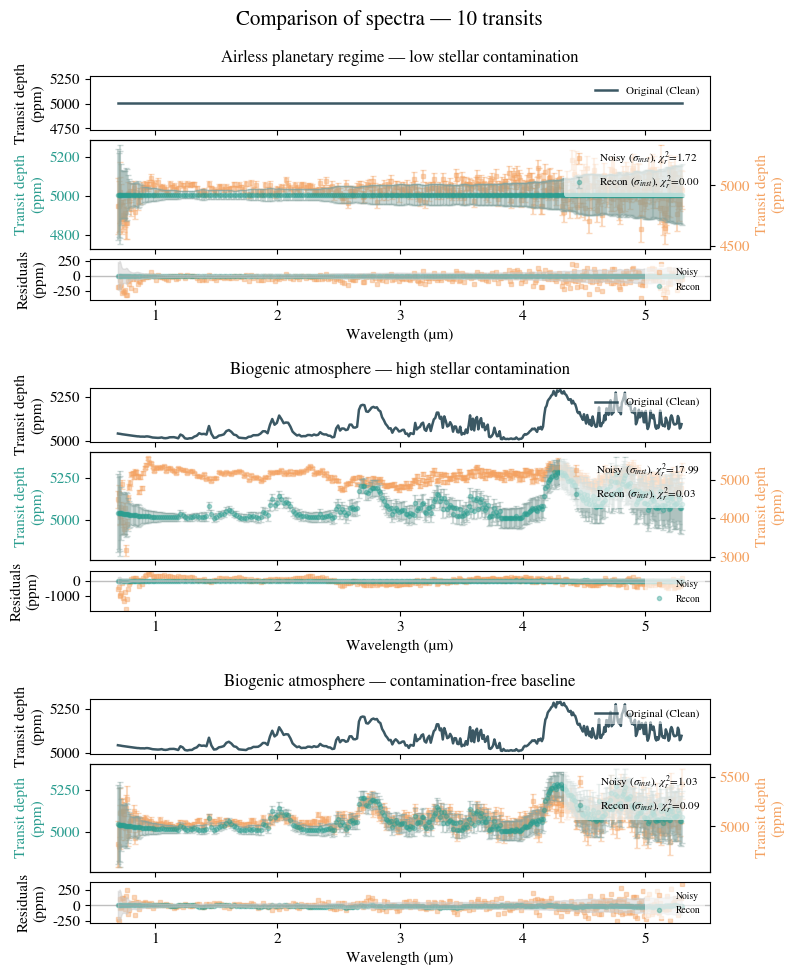

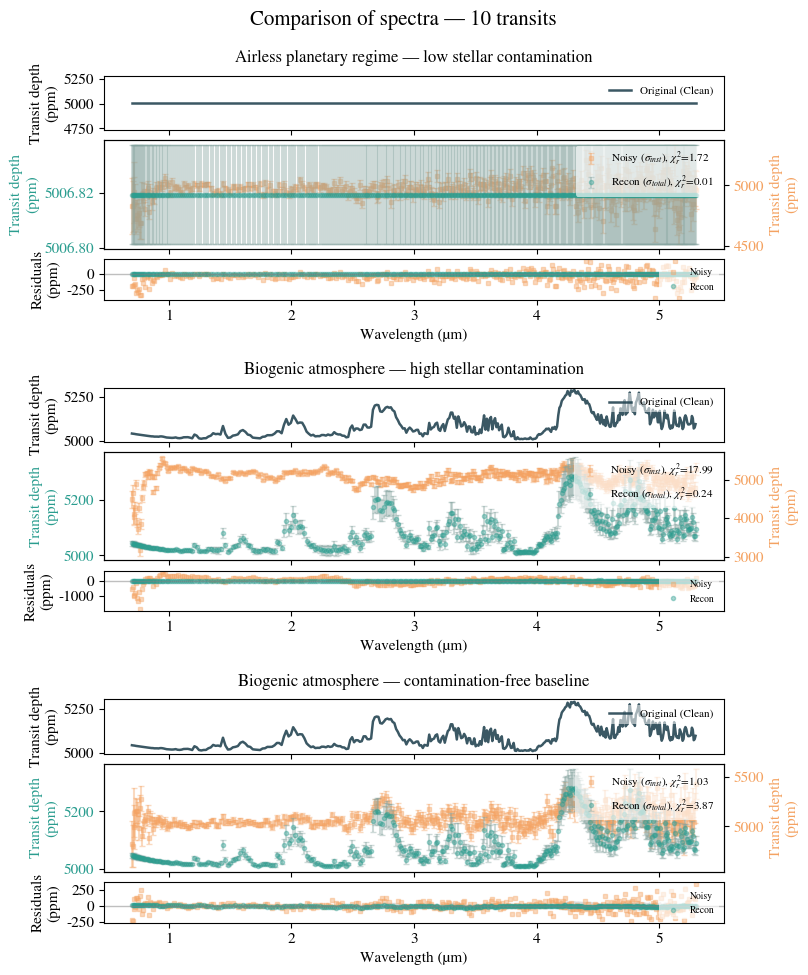

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
# --- CAMBIO 1: Importar la clase necesaria ---
from matplotlib.ticker import ScalarFormatter

# --- 1. Carga de Datos ---
# Se asume que tus variables ya existen en el entorno.
# El código continuará desde aquí usando tus datos.
try:
    y_recon_all = recon_mean
    sigma_total_all = sigma_total
    y_clean_all = X_clean_raw.values
    y_noisy_all = X_noisy_raw.values
    sigma_inst = errors
    waves_i = waves[::-1]
except NameError as e:
    print(f"Error: Una de las variables necesarias no está definida. Asegúrate de que tus datos estén cargados.")
    print(f"Variable faltante: {e}")
    # Detener la ejecución si los datos no están listos.
    # Puedes comentar la siguiente línea si prefieres que continúe.
    raise 

# --- 2. Función para crear el plot con la corrección ---
def create_plot_with_your_style(uncertainty_type: str):
    """
    Genera un gráfico con tu estilo original y las correcciones de formato del eje Y.
    """
    # --- Configuración ---
    colors = {
        'original':      '#264653',
        'reconstructed': '#2A9D8F',
        'noisy_points':  '#F4A261',
        'fill_uq_resid': '#cccccc80'
    }
    idx_list = [46677, 42873, 1401]
    custom_titles = [
        "Airless planetary regime — low stellar contamination",
        "Biogenic atmosphere — high stellar contamination",
        "Biogenic atmosphere — contamination-free baseline"
    ]
    plt.rcParams.update({'font.size': 11})

    n_groups = len(idx_list)
    spacer = 2.5
    height_ratios = [val for i in range(n_groups) for val in ([2, 4, 1.5] + ([spacer] if i < n_groups - 1 else []))]

    fig = plt.figure(figsize=(8, 11))
    gs = GridSpec(len(height_ratios), 1, height_ratios=height_ratios, hspace=0.15)

    for i, idx in enumerate(idx_list):
        base = 4 * i
        ax_orig   = fig.add_subplot(gs[base])
        ax_mix    = fig.add_subplot(gs[base + 1], sharex=ax_orig)
        ax_resid  = fig.add_subplot(gs[base + 2], sharex=ax_orig)

        ax_orig.tick_params(labelbottom=False)
        ax_mix.tick_params(labelbottom=False)

        # --- Selección de datos y variables ---
        y_clean, y_noisy, y_recon = y_clean_all[idx], y_noisy_all[idx], y_recon_all[idx]

        if uncertainty_type == 'instrumental':
            sigma_recon = sigma_inst
            recon_sigma_label = r'\sigma_{inst}'
        else:
            sigma_recon = sigma_total_all[idx]
            recon_sigma_label = r'\sigma_{total}'

        chi2r_n = chi2_r(y_clean[None, :], y_noisy[None, :], sigma_inst, p=0)[0]
        chi2r_recon = chi2_r(y_clean[None, :], y_recon[None, :], sigma_recon, p=0)[0]

        y_clean_ppm, y_noisy_ppm, y_recon_ppm = y_clean*1e6, y_noisy*1e6, y_recon*1e6
        sigma_inst_ppm, sigma_recon_ppm = sigma_inst*1e6, sigma_recon*1e6

        # --- Panel 1 y 2 ---
        ax_orig.plot(waves_i, y_clean_ppm, color=colors['original'], lw=1.8, alpha=0.9, label='Original (Clean)')
        ax_orig.set_ylabel("Transit depth\n(ppm)")
        ax_orig.set_title(custom_titles[i], fontsize=12)
        leg1 = ax_orig.legend(fontsize=8, loc='upper right', frameon=True, fancybox=True,
                              facecolor='white', edgecolor='none', framealpha=0.55)
        leg1.set_zorder(1000)
        
        ax_mix_r = ax_mix.twinx()

        # --- INICIO DE LA CORRECCIÓN ---
        # 1. Crear un formateador que deshabilita el "offset" (el +5.006e3)
        formatter = ScalarFormatter(useOffset=False)
        formatter.set_scientific(False) # También evita notación científica

        # 2. Aplicarlo a todos los ejes Y que muestran la profundidad del tránsito
        ax_orig.yaxis.set_major_formatter(formatter)
        ax_mix.yaxis.set_major_formatter(formatter)
        ax_mix_r.yaxis.set_major_formatter(formatter)
        # --- FIN DE LA CORRECCIÓN ---

        ax_mix_r.grid(False)
        ax_mix.set_zorder(3); ax_mix_r.set_zorder(2)
        ax_mix.patch.set_alpha(0.0); ax_mix_r.patch.set_alpha(0.0)
        ax_mix.set_ylabel("Transit depth\n(ppm)", color=colors['reconstructed'])
        ax_mix.tick_params(axis='y', labelcolor=colors['reconstructed'])
        ax_mix_r.set_ylabel("Transit depth\n(ppm)", color=colors['noisy_points'])
        ax_mix_r.tick_params(axis='y', labelcolor=colors['noisy_points'])
        

        noisy_label = rf"Noisy ($\sigma_{{inst}}$), $\chi^2_r$={chi2r_n:.2f}"
        ax_mix_r.errorbar(waves_i, y_noisy_ppm, yerr=sigma_inst_ppm, color=colors['noisy_points'],
                          fmt='s', capsize=2, alpha=0.4, ms=3, label=noisy_label, zorder=8)
        recon_label = rf"Recon (${recon_sigma_label}$), $\chi^2_r$={chi2r_recon:.2f}"
        ax_mix.errorbar(waves_i, y_recon_ppm, yerr=sigma_recon_ppm, color=colors['reconstructed'],
                        fmt='o', capsize=2, alpha=0.4, ms=3, label=recon_label, ecolor='#85A39F', zorder=9)
        

        lines1, labels1 = ax_mix.get_legend_handles_labels()
        lines2, labels2 = ax_mix_r.get_legend_handles_labels()
        leg2 = ax_mix.legend(lines2 + lines1, labels2 + labels1, fontsize=8, loc='upper right',
                            frameon=True, fancybox=True, facecolor='white', edgecolor='none', framealpha=0.65)
        leg2.set_zorder(1000)

        # --- Panel 3 ---
        resid_n = (y_noisy - y_clean) * 1e6
        resid_r = (y_recon - y_clean) * 1e6
        
        if uncertainty_type == 'instrumental':
            ax_resid.fill_between(waves_i, -sigma_recon_ppm, sigma_recon_ppm,
                                  color=colors['fill_uq_resid'], zorder=5, label=None)
        else:
            ax_resid.fill_between(waves_i, -sigma_recon_ppm, sigma_recon_ppm,
                                  color=colors['fill_uq_resid'], zorder=0,)
        
        ax_resid.plot(waves_i, resid_n, 's', color=colors['noisy_points'], alpha=0.4, ms=3, label='Noisy', zorder=1)
        ax_resid.plot(waves_i, resid_r, 'o', color=colors['reconstructed'], alpha=0.4, ms=3, label='Recon', zorder=2)

        
        ax_resid.axhline(0, color='gray', lw=1, alpha=0.5)
        ax_resid.set_ylabel("Residuals\n(ppm)")
        ax_resid.set_xlabel("Wavelength (µm)", fontsize=11)
        ax_resid.legend(fontsize=7, loc='upper right', 
         frameon=True, fancybox=True, facecolor='white', edgecolor='none', framealpha=0.65)

    # --- Título y guardado con formato final ---
    supt_title = f"Comparison of spectra — {N_TRANSITS} transits"
    fig.suptitle(supt_title, fontsize=15, y=0.94)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    filename = f"plots/exp0-final_style-{uncertainty_type}_uq-{N_TRANSITS}Transit"
    # Descomenta las siguientes líneas si quieres guardar las imágenes
    plt.savefig(f"{filename}.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"{filename}.svg", bbox_inches='tight')
    # print(f">>> Saved plot: {filename}.png")
    
    plt.show()

# --- 3. Generar los dos plots finales ---
# Plot 1: Con INCERTIDUMBRE INSTRUMENTAL (tu versión personal)
create_plot_with_your_style(uncertainty_type='instrumental')

# Plot 2: Con INCERTIDUMBRE TOTAL (la versión para presentar)
create_plot_with_your_style(uncertainty_type='total')

# Análisis por contaminación estelar y SNR

In [13]:
import pandas as pd

def filter_rows(df):
    """
    Filters rows of a DataFrame where at least one of the columns
    "atm CH4", "atm O3", or "atm H2O" has a value >= -8.
    Returns the DataFrame unchanged if none of these columns are present.
    """
    filter_columns = ["atm CH4", "atm O3", "atm H2O"]
    present_columns = [col for col in filter_columns if col in df.columns]

    for chem in present_columns:
        df = df[df[chem] >= -8]
        # Set .data and .params attributes on the final DataFrame
        df.data = df.iloc[:, -n_points:]
        df.params = df.iloc[:, :-n_points]
    return df


try:
    airless_data_clean = pd.read_csv("spec_data/airless_data.csv")
    airless_data_clean = mult_df(airless_data_clean, n_points, 0)
except Exception as e:
    print(f"Error processing airless_data: {e}")

try:
    CO2_data_clean = pd.read_csv("spec_data/CO2_data.csv")
    CO2_data_clean = mult_df(CO2_data_clean, n_points, 0)
except Exception as e:
    print(f"Error processing CO2_data: {e}")

try:
    CH4_data_clean = pd.read_csv("spec_data/CH4_data.csv")
    CH4_data_clean = filter_rows(CH4_data_clean)
    CH4_data_clean = mult_df(CH4_data_clean, n_points, 0)
except Exception as e:
    print(f"Error processing CH4_data: {e}")

try:
    O3_data_clean = pd.read_csv("spec_data/O3_data.csv")
    O3_data_clean = filter_rows(O3_data_clean)
    O3_data_clean = mult_df(O3_data_clean, n_points, 0)
except Exception as e:
    print(f"Error processing O3_data: {e}")

try:
    H2O_data_clean = pd.read_csv("spec_data/H2O_data.csv")
    H2O_data_clean = filter_rows(H2O_data_clean)
    H2O_data_clean = mult_df(H2O_data_clean, n_points, 0)
except Exception as e:
    print(f"Error processing H2O_data: {e}")

try:
    CH4_O3_data_clean = pd.read_csv("spec_data/CH4_O3_data.csv")
    CH4_O3_data_clean = filter_rows(CH4_O3_data_clean)
    CH4_O3_data_clean = mult_df(CH4_O3_data_clean, n_points, 0)
except Exception as e:
    print(f"Error processing CH4_O3_data: {e}")

try:
    CH4_H2O_data_clean = pd.read_csv("spec_data/CH4_H2O_data.csv")
    CH4_H2O_data_clean = filter_rows(CH4_H2O_data_clean)
    CH4_H2O_data_clean = mult_df(CH4_H2O_data_clean, n_points, 0)
except Exception as e:
    print(f"Error processing CH4_H2O_data: {e}")

try:
    O3_H2O_data_clean = pd.read_csv("spec_data/O3_H2O_data.csv")
    O3_H2O_data_clean = filter_rows(O3_H2O_data_clean)
    O3_H2O_data_clean = mult_df(O3_H2O_data_clean, n_points, 0)
except Exception as e:
    print(f"Error processing O3_H2O_data: {e}")

try:
    CH4_O3_H2O_data_clean = pd.read_csv("spec_data/CH4_O3_H2O_data.csv")
    CH4_O3_H2O_data_clean = filter_rows(CH4_O3_H2O_data_clean)
    CH4_O3_H2O_data_clean = mult_df(CH4_O3_H2O_data_clean, n_points, 0)
except Exception as e:
    print(f"Error processing CH4_O3_H2O_data: {e}")


C:\Users\User\AppData\Local\Temp\ipykernel_61732\876726031.py:19: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_61732\876726031.py:20: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, :-n_points]
C:\Users\User\AppData\Local\Temp\ipykernel_61732\876726031.py:19: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_61732\876726031.py:20: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.py

In [14]:
CO2_data_clean.params

,f_spot,f_fac,Unnamed: 0,atm CH4,atm H2O,atm O3,sma,seed,p_radius,p_mass,...,atm base_pressure,atm top_pressure,atm fill_gas,atm seed,atm CO2,s temperature,s radius,s mass,s seed,label
0,0.0,0.0,0,0,0,0,0.02925,1.715549e+09,0.92,0.692,...,100000.0,0.001,N2,1.715549e+09,-2,2566,0.1192,0.0898,1.715549e+09,"[0, 0, 0]"
1,0.0,0.0,0,0,0,0,0.02925,NaN,0.92,0.692,...,100000.0,0.001,N2,NaN,-2,2566,0.1192,0.0898,NaN,"[0, 0, 0]"
2,0.0,0.0,0,0,0,0,0.02925,NaN,0.92,0.692,...,100000.0,0.001,N2,NaN,-2,2566,0.1192,0.0898,NaN,"[0, 0, 0]"


In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from tqdm import tqdm
import pickle

# ===========================================================
# CONFIG / CONSTANTES (ajusta los valores como en tu script)
# ===========================================================
N_TRANSITS_LIST = [2, 6, 13, 37, 100]

f_spot_values = [0, 0.01, 0.08, 0.26]
f_fac_values  = [0, 0.08, 0.54, 0.70]
factor        = 10 / 8

MONTE_CARLO_REPEATS = 1000   # input-noise MC (aleatoria)
T_PASSES_DROPOUT    = 100    # MC Dropout (epistémica)
EPS_SIGMA           = 1e-12  # piso numérico para sigma_total

# n_points = 288  # ya deberías tenerlo definido antes

# ===========================================================
# FUNCIONES AUXILIARES (asegúrate que existan/importadas)
# ===========================================================
# - get_pandexo_noise_from_file(...)
# - generate_df_with_noise_std(...)
# - chi2_r(...)
# - mc_reconstruct_mean_std_full_anchor_clean(...)
# - mc_dropout_sigma_anchor_clean(...)
# - combine_uncertainties(...)
# - autoencoder (ya cargado)
# - CH4_O3_H2O_data, airless_data,
#   CH4_O3_H2O_data_clean, airless_data_clean

def filtrar_data(df, f_spot_val, f_fac_val):
    """Subset matching the stellar heterogeneity pair."""
    return df[(df["f_spot"] == f_spot_val) & (df["f_fac"] == f_fac_val)]

# ===========================================================
# CONSTRUIR DATASET LIMPIO MAESTRO (una sola vez)
# ===========================================================
print("Building master CLEAN dataset (one-time)...")
n_ch4_o3_h2o_maestro = int(2 * factor * factor * factor)
n_airless_maestro    = int(100 * 3)

df_clean_maestro = pd.concat(
    [
        generate_df_with_noise_std(CH4_O3_H2O_data_clean, n_ch4_o3_h2o_maestro, 0),
        generate_df_with_noise_std(airless_data_clean,    n_airless_maestro,    0),
    ],
    ignore_index=True,
)
print("Master CLEAN dataset ready. ✅")

# ===========================================================
# CONTENEDORES DE RESULTADOS
# ===========================================================
# 1) Agregados por (f_spot, f_fac, n_transits) — como antes
all_results = {}

# 2) NUEVO: datos a nivel de muestra/píxel para ajustar α
all_samples = {}   # (f_spot, f_fac) -> {nt: dict(...)} 

# ===========================================================
# BUCLE PRINCIPAL
# ===========================================================
print("\nStarting sensitivity & UQ analysis...")

for f_spot_val in f_spot_values:
    for f_fac_val in f_fac_values:
        # Sólo procesar (0,0) o pares donde ambos son no-cero
        if (f_spot_val == 0) ^ (f_fac_val == 0):
            continue

        # --- Agregados por este par (f_spot, f_fac) ---
        scores = {
            "n_transits": [],
            "chi2r_noisy_clean_inst": [],
            "chi2r_recon_clean_inst": [],
            "chi2r_recon_clean_total": [],
            "sigma_inst_mean_lambda": [],
            "sigma_ale_mean_lambda": [],
            "sigma_epi_mean_lambda": [],
            "sigma_total_mean_lambda": [],
        }

        # --- NUEVO: contenedor de samples completos ---
        samples_for_combo = {}   # nt -> dict

        # Para este combo usamos el dataset limpio maestro completo
        df_clean_filtered = df_clean_maestro

        desc = f"Processing f_spot={f_spot_val}, f_fac={f_fac_val}"
        for nt in tqdm(N_TRANSITS_LIST, desc=desc, leave=True):

            # 1) Ruido instrumental para este n_transits (vector por λ)
            instrumental_noise = get_pandexo_noise_from_file(
                "pandexo_spec.txt", n_transits=nt, plot=False
            )
            instrumental_noise = instrumental_noise[::-1]
            instrumental_noise = np.asarray(instrumental_noise, dtype=np.float32)
            if instrumental_noise.ndim != 1:
                raise ValueError("Expected 1D instrumental noise vector per wavelength.")

            # 2) Construir dataset RUIDOSO
            df_noisy = pd.concat(
                [
                    generate_df_with_noise_std(
                        CH4_O3_H2O_data, n_ch4_o3_h2o_maestro, instrumental_noise
                    ),
                    generate_df_with_noise_std(
                        airless_data,    n_airless_maestro,    instrumental_noise
                    ),
                ],
                ignore_index=True,
            )

            # 3) Filtrar por (f_spot, f_fac)
            df_noisy_filtered = filtrar_data(df_noisy, f_spot_val, f_fac_val)

            print(f"\n>> n_transits={nt}, f_spot={f_spot_val}, f_fac={f_fac_val}")
            print(f"   - Instrumental noise mean (scalar over λ): {instrumental_noise.mean():.6e}")
            print(f"   - # noisy samples: {df_noisy_filtered.shape[0]}")
            print(f"   - # clean samples: {df_clean_filtered.shape[0]}")

            if df_noisy_filtered.empty:
                # Agregados con NaN para mantener longitud
                scores["n_transits"].append(nt)
                scores["chi2r_noisy_clean_inst"].append(np.nan)
                scores["chi2r_recon_clean_inst"].append(np.nan)
                scores["chi2r_recon_clean_total"].append(np.nan)

                nan_vec = np.full((n_points,), np.nan, dtype=np.float32)
                scores["sigma_inst_mean_lambda"].append(nan_vec.copy())
                scores["sigma_ale_mean_lambda"].append(nan_vec.copy())
                scores["sigma_epi_mean_lambda"].append(nan_vec.copy())
                scores["sigma_total_mean_lambda"].append(nan_vec.copy())

                # Para samples dejamos un marcador vacío
                samples_for_combo[nt] = None
                continue

            # 4) Extraer bloques espectrales
            X_noisy_raw = df_noisy_filtered.iloc[:, -n_points:]
            X_clean_raw = df_clean_filtered.iloc[:, -n_points:]

            if X_noisy_raw.shape[0] != X_clean_raw.shape[0]:
                raise RuntimeError(
                    f"Row mismatch clean/noisy: {X_clean_raw.shape[0]} vs {X_noisy_raw.shape[0]}"
                )

            # 5) UQ: sigmas aleatoria, epistémica y total
            _, sigma_ale = mc_reconstruct_mean_std_full_anchor_clean(
                autoencoder=autoencoder,
                x_noisy_raw=X_noisy_raw,
                x_clean_raw=X_clean_raw,
                sigma=instrumental_noise,
                n_repeat=MONTE_CARLO_REPEATS,
            )  # [n_rows, n_points]

            recon_mean, sigma_epi = mc_dropout_sigma_anchor_clean(
                autoencoder=autoencoder,
                x_noisy_raw=X_noisy_raw,
                x_clean_raw=X_clean_raw,
                t_passes=T_PASSES_DROPOUT,
            )  # recon_mean: [n_rows, n_points], sigma_epi idem

            sigma_total = combine_uncertainties(
                sigma_ale=sigma_ale, sigma_epi=sigma_epi, floor=EPS_SIGMA
            )  # [n_rows, n_points]

            # 6) Medias por longitud de onda
            sigma_inst_mean_lambda  = instrumental_noise.astype(np.float32)        # [n_points]
            sigma_ale_mean_lambda   = np.nanmean(sigma_ale,  axis=0).astype(np.float32)
            sigma_epi_mean_lambda   = np.nanmean(sigma_epi,  axis=0).astype(np.float32)
            sigma_total_mean_lambda = np.nanmean(sigma_total,axis=0).astype(np.float32)

            # 7) Chi-cuadrado reducido (puede devolver vector o escalar; lo normalizamos a np.array)
            chi2r_1 = np.asarray(
                chi2_r(X_clean_raw.values, X_noisy_raw.values, instrumental_noise, p=0),
                dtype=np.float32,
            )
            chi2r_2 = np.asarray(
                chi2_r(X_clean_raw.values, recon_mean, instrumental_noise, p=0),
                dtype=np.float32,
            )
            chi2r_3 = np.asarray(
                chi2_r(X_clean_raw.values, recon_mean, sigma_total, p=0),
                dtype=np.float32,
            )

            print(f"   - χ²_r (noisy vs clean | inst): {float(np.mean(chi2r_1)):.4f}")
            print(f"   - χ²_r (recon vs clean | inst): {float(np.mean(chi2r_2)):.4f}")
            print(f"   - χ²_r (recon vs clean | total): {float(np.mean(chi2r_3)):.4f}")

            # --- Guardar agregados ---
            scores["n_transits"].append(nt)
            scores["chi2r_noisy_clean_inst"].append(float(np.mean(chi2r_1)))
            scores["chi2r_recon_clean_inst"].append(float(np.mean(chi2r_2)))
            scores["chi2r_recon_clean_total"].append(float(np.mean(chi2r_3)))
            scores["sigma_inst_mean_lambda"].append(sigma_inst_mean_lambda)
            scores["sigma_ale_mean_lambda"].append(sigma_ale_mean_lambda)
            scores["sigma_epi_mean_lambda"].append(sigma_epi_mean_lambda)
            scores["sigma_total_mean_lambda"].append(sigma_total_mean_lambda)

            # --- NUEVO: guardar TODAS LAS MUESTRAS para este nt ---
            samples_for_combo[nt] = {
                # ruido inst. por λ (mismo para todas las filas en este nt)
                "sigma_inst_lambda": instrumental_noise.astype(np.float32),   # [n_points]

                # sigmas por espectro y λ
                "sigma_ale":   sigma_ale.astype(np.float32),     # [n_rows, n_points]
                "sigma_epi":   sigma_epi.astype(np.float32),
                "sigma_total": sigma_total.astype(np.float32),

                # reconstrucciones y verdaderos
                "y_true": X_clean_raw.values.astype(np.float32),
                "y_pred": recon_mean.astype(np.float32),

                # χ²_r por espectro (por si quieres mirar después)
                "chi2r_noisy_clean_inst": chi2r_1,
                "chi2r_recon_clean_inst": chi2r_2,
                "chi2r_recon_clean_total": chi2r_3,
            }

        # Al final de este par (f_spot, f_fac):
        all_results[(f_spot_val, f_fac_val)] = scores
        all_samples[(f_spot_val, f_fac_val)] = samples_for_combo

print("\nDone! ✅")

# ===========================================================
# GUARDAR PKL
# ===========================================================
# 1) Agregado por n_transits (como antes)
output_filename = "results_by_transits_airless_vs_ch4o3h2o_proportional.pkl"
with open(output_filename, "wb") as f:
    pickle.dump(all_results, f)
print(f"Results saved to: '{output_filename}'")

# 2) NUEVO: TODAS LAS MUESTRAS
output_filename_full = "results_by_transits_airless_vs_ch4o3h2o_samples.pkl"
with open(output_filename_full, "wb") as f:
    pickle.dump(all_samples, f)
print(f"Sample-level results saved to: '{output_filename_full}'")


Building master CLEAN dataset (one-time)...
Using scalar noise_std = 0
Using scalar noise_std = 0
Master CLEAN dataset ready. ✅

Starting sensitivity & UQ analysis...


Processing f_spot=0, f_fac=0:   0%|          | 0/5 [00:00<?, ?it/s]

Running Single Case w/ User Instrument Dict


c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:988: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:1251: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:2958: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:2910: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()


Starting Out of Transit Simulation


...

Starting Out of Transit Simulation


c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:
c:\Users\User\anaconda3\Lib\site-packages\pandexo\engine\jwst.py:176: ResourceWarning: unclosed file <_io.BufferedReader name='C:\\Proyectos\\Astro\\Pandexo\\pandeia_data-3.0rc3\\jwst\\nirspec\\qe\\jwst_nirspec_qe_20160902193401.fits'>
  out = remove_QY(out, instrument)
c:\Users\User\anaconda3\Lib\site-packages\pandexo\engine\justdoit.py:394: ResourceWarning: unclosed file <_io.BufferedWriter name='c:\\Proyectos\\Astro\\AEspectra\\exp 0\\singlerun.p'>
  if save_file: pkl.dump(results, open(os.path.join(output_path,output_file),'wb'))


End out of Transit
Starting In Transit Simulation
End In Transit
Using per-wavelength noise_std vector
Using per-wavelength noise_std vector

>> n_transits=100, f_spot=0.26, f_fac=0.7
   - Instrumental noise mean (scalar over λ): 2.186545e-05
   - # noisy samples: 4908
   - # clean samples: 4908


Processing f_spot=0.26, f_fac=0.7: 100%|██████████| 5/5 [09:54<00:00, 118.85s/it]

   - χ²_r (noisy vs clean | inst): 167.6917
   - χ²_r (recon vs clean | inst): 0.2553
   - χ²_r (recon vs clean | total): 0.2785

Done! ✅
Results saved to: 'results_by_transits_airless_vs_ch4o3h2o_proportional.pkl'


In [ ]:
import pickle
from typing import Tuple, Callable, Optional

import numpy as np
from scipy.optimize import minimize


# ============================================================
# 1. Cargar y aplanar datos desde el pickle de "samples"
#    (results_by_transits_airless_vs_ch4o3h2o_samples.pkl)
# ============================================================
def load_flat_arrays_from_samples(
    samples_pkl_path: str,
    max_points: Optional[int] = 1_000_000,
    random_state: int = 0,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Lee el pkl '..._samples.pkl' y devuelve cuatro arrays 1D grandes:

      sigma_inst_all : ruido instrumental por píxel
      sigma_ale_all  : sigma aleatoria por píxel
      sigma_epi_all  : sigma epistémica por píxel
      resid2_all     : residuo^2 = (y_true - y_pred)^2 por píxel

    Opcionalmente submuestrea hasta `max_points` píxeles para que
    la optimización no sea eterna.
    """
    with open(samples_pkl_path, "rb") as f:
        samples = pickle.load(f)

    sigma_inst_list = []
    sigma_ale_list  = []
    sigma_epi_list  = []
    resid2_list     = []

    for (f_spot, f_fac), by_nt in samples.items():
        for nt, d in by_nt.items():
            if d is None:
                continue

            # --- Recuperar arrays tal como los guardaste ---
            sigma_inst_lambda = np.asarray(d["sigma_inst_lambda"], dtype=np.float64)  # [D]
            sigma_ale  = np.asarray(d["sigma_ale"], dtype=np.float64)                 # [N, D]
            sigma_epi  = np.asarray(d["sigma_epi"], dtype=np.float64)                 # [N, D]
            y_true     = np.asarray(d["y_true"], dtype=np.float64)                    # [N, D]
            y_pred     = np.asarray(d["y_pred"], dtype=np.float64)                    # [N, D]

            resid2 = (y_true - y_pred) ** 2                                           # [N, D]

            N, D = sigma_ale.shape
            # broadcast de sigma_inst_lambda a [N, D]
            sigma_inst_2d = np.broadcast_to(sigma_inst_lambda[None, :], (N, D))

            sigma_inst_list.append(sigma_inst_2d.ravel())
            sigma_ale_list.append(sigma_ale.ravel())
            sigma_epi_list.append(sigma_epi.ravel())
            resid2_list.append(resid2.ravel())

    sigma_inst_all = np.concatenate(sigma_inst_list)
    sigma_ale_all  = np.concatenate(sigma_ale_list)
    sigma_epi_all  = np.concatenate(sigma_epi_list)
    resid2_all     = np.concatenate(resid2_list)

    # --- Submuestreo opcional para que no haya demasiados puntos ---
    if max_points is not None and sigma_inst_all.size > max_points:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(sigma_inst_all.size, size=max_points, replace=False)
        sigma_inst_all = sigma_inst_all[idx]
        sigma_ale_all  = sigma_ale_all[idx]
        sigma_epi_all  = sigma_epi_all[idx]
        resid2_all     = resid2_all[idx]

    return sigma_inst_all, sigma_ale_all, sigma_epi_all, resid2_all


# ============================================================
# 2. Ajuste de alpha(sigma_inst) = exp(u) * sigma_inst**v
#    minimizando que chi^2_r ~ 1
# ============================================================
def fit_alpha_powerlaw_from_samples(
    samples_pkl_path: str,
    max_points: Optional[int] = 1_000_000,
    clip_alpha_min: Optional[float] = 1.0,
    random_state: int = 0,
) -> Tuple[Callable[[np.ndarray], np.ndarray], Tuple[float, float]]:
    """
    Ajusta una ley de potencia para alpha(sigma_inst):

        alpha(sigma_inst) = exp(u) * sigma_inst**v

    usando todas las muestras del pkl:

      - sigma_ale, sigma_epi, sigma_inst y residuo^2.

    La pérdida que se minimiza es:

        L(u,v) = mean_j ( chi_j^2(u,v) - 1 )^2

    donde

        chi_j^2(u,v) = resid2_j / sigma_tot_cal_j(u,v)^2

        sigma_tot_cal_j^2 = sigma_epi_j^2 + (alpha_j * sigma_ale_j)^2

    Parámetros
    ----------
    samples_pkl_path : str
        Ruta a 'results_by_transits_airless_vs_ch4o3h2o_samples.pkl'.
    max_points : int | None
        Máx. número de píxeles para usar (submuestreo aleatorio). None = usar todos.
    clip_alpha_min : float | None
        Si no es None, impone alpha >= clip_alpha_min (típicamente 1.0).
    random_state : int
        Semilla para el submuestreo.

    Retorna
    -------
    alpha_func : Callable
        Función vectorizada: alpha_func(sigma_inst) -> alpha
    (u_opt, v_opt) : Tuple[float, float]
        Parámetros óptimos de la ley de potencia.
    """
    # 1) Cargar y aplanar arrays
    sigma_inst_all, sigma_ale_all, sigma_epi_all, resid2_all = load_flat_arrays_from_samples(
        samples_pkl_path=samples_pkl_path,
        max_points=max_points,
        random_state=random_state,
    )

    # Evitar problemas numéricos
    sigma_inst_all = np.maximum(sigma_inst_all, 1e-30)
    sigma_ale_all  = np.maximum(sigma_ale_all,  1e-30)
    sigma_epi_all  = np.maximum(sigma_epi_all,  0.0)

    # 2) Definir la pérdida L(u,v)
    def loss(theta: np.ndarray) -> float:
        u, v = theta
        # alpha_j = exp(u) * sigma_inst_j ** v
        alpha = np.exp(u) * (sigma_inst_all ** v)
        if clip_alpha_min is not None:
            alpha = np.maximum(alpha, clip_alpha_min)

        sigma_tot2_cal = sigma_epi_all**2 + (alpha * sigma_ale_all)**2
        chi2_pixel = resid2_all / (sigma_tot2_cal + 1e-30)

        # Queremos chi2 ~ 1 => minimizamos (chi2 - 1)^2
        return float(np.mean((chi2_pixel - 1.0)**2))

    # 3) Inicialización: alpha ~ 1 ⇒ u=0, v=0
    theta0 = np.array([0.0, 0.0], dtype=np.float64)

    # 4) Optimización (Nelder–Mead: robusto, sin gradiente)
    res = minimize(
        loss,
        x0=theta0,
        method="Nelder-Mead",
        options={"maxiter": 500, "xatol": 1e-4, "fatol": 1e-4},
    )

    u_opt, v_opt = res.x
    print("Optimización alpha(sigma_inst):")
    print(f"  u_opt = {u_opt:.6f}, v_opt = {v_opt:.6f}")
    print(f"  loss  = {res.fun:.4e}, success = {res.success}")

    # 5) Construir la función alpha(sigma_inst) ya entrenada
    def alpha_func(sigma_inst: np.ndarray) -> np.ndarray:
        sigma_inst = np.asarray(sigma_inst, dtype=np.float64)
        sigma_inst = np.maximum(sigma_inst, 1e-30)
        alpha = np.exp(u_opt) * (sigma_inst ** v_opt)
        if clip_alpha_min is not None:
            alpha = np.maximum(alpha, clip_alpha_min)
        return alpha

    return alpha_func, (u_opt, v_opt)


# ============================================================
# 3. Ejemplo de uso
# ============================================================
if __name__ == "__main__":
    # Ruta al pickle de samples que genera tu script grande
    samples_path = "results_by_transits_airless_vs_ch4o3h2o_samples.pkl"

    # Ajustar alpha(sigma_inst)
    alpha_func, (u_opt, v_opt) = fit_alpha_powerlaw_from_samples(
        samples_pkl_path=samples_path,
        max_points=1_000_000,  # puedes subirlo o poner None
        clip_alpha_min=1.0,    # no reducir barras por debajo de las actuales
        random_state=42,
    )

    # Ejemplo tonto: ver qué alpha da para un rango de sigma_inst típico
    test_sigma_inst = np.logspace(-5, -3, 5)  # por ejemplo
    print("sigma_inst de prueba :", test_sigma_inst)
    print("alpha(sigma_inst)    :", alpha_func(test_sigma_inst))


In [17]:
all_results

{(0, 0): {'n_transits': [2, 6, 13, 37, 100],
  'chi2r_noisy_clean_inst': [0.9987053462470992,
   1.000665177511449,
   1.0001192125336165,
   1.0005380850646473,
   0.9989584783077383],
  'chi2r_recon_clean_inst': [0.0973745213531463,
   0.09163277036952765,
   0.09927603821064622,
   0.1346361889205835,
   0.23892335247475432],
  'chi2r_recon_clean_total': [11.43908339746206,
   2.552170814913481,
   1.144206849375675,
   0.5454096553090938,
   0.3136435008113546]},
 (0.01, 0.08): {'n_transits': [2, 6, 13, 37, 100],
  'chi2r_noisy_clean_inst': [1.1511803050377745,
   1.4561933736104782,
   1.9844895122875412,
   3.806042229473133,
   8.582905959125293],
  'chi2r_recon_clean_inst': [0.08490954849145715,
   0.08045115319515354,
   0.09028966795597863,
   0.1304304181386401,
   0.23605529411999115],
  'chi2r_recon_clean_total': [8.744875556033863,
   1.5346704079519995,
   0.7327827303215644,
   0.38177276930200643,
   0.26265428485167075]},
 (0.01, 0.54): {'n_transits': [2, 6, 13, 37, 1

## Plot

<>:81: SyntaxWarning: invalid escape sequence '\c'
<>:81: SyntaxWarning: invalid escape sequence '\c'
C:\Users\User\AppData\Local\Temp\ipykernel_36092\938589867.py:81: SyntaxWarning: invalid escape sequence '\c'
  fig.suptitle('$\chi^2_r$ Analisys vs. Number of Transits', fontsize=18, y=0.98, weight='bold')


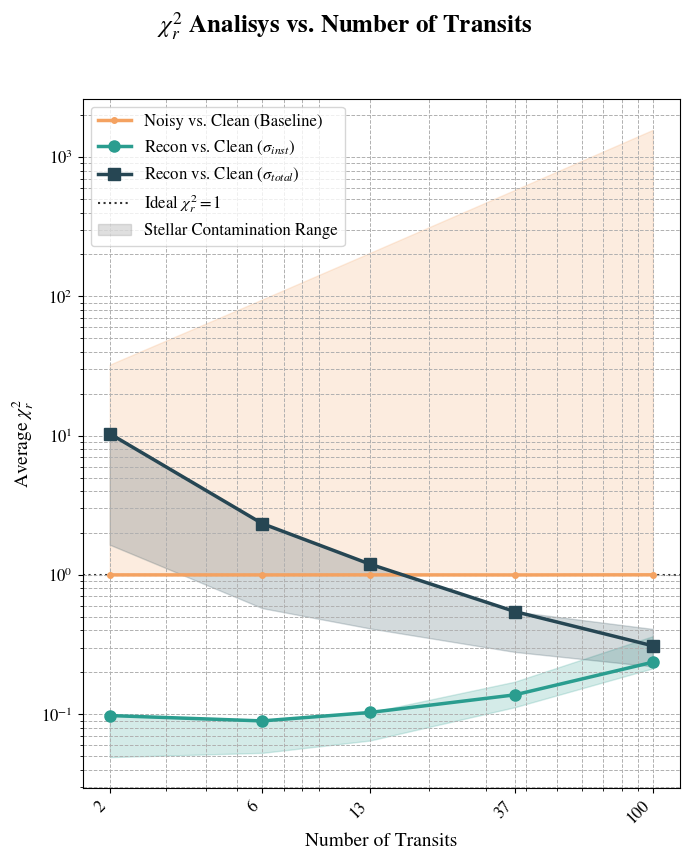

In [19]:
import pickle

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os

# ============================
# Cargar Resultados
# ============================
filename = 'results_by_transits_airless_vs_ch4o3h2o_proportional.pkl'
try:
    with open(filename, 'rb') as f:
        all_results = pickle.load(f)
except FileNotFoundError:
    raise RuntimeError(f"Archivo '{filename}' no encontrado. Asegúrate de que el script de cálculo se haya ejecutado y el archivo esté en la misma carpeta.")

# Verificar que el caso base (sin contaminación) existe
base_key = (0.0, 0.0)
case_base = all_results.get(base_key)
if case_base is None:
    raise RuntimeError("No se encontraron datos para el caso base (f_spot=0, f_fac=0).")

# Extraer los valores del eje X
transits_plot = case_base['n_transits']
x_vals = np.array(transits_plot, dtype=float)

# ============================
# Configuración de Plots
# ============================
# <<< CORRECCIÓN: Se cambiaron los nombres de las métricas para que coincidan con el archivo .pkl
# Se reemplazó '_vs_clean_' por '_clean_'.
metrics = [
    'chi2r_noisy_clean_inst',
    'chi2r_recon_clean_inst',
    'chi2r_recon_clean_total'
]

# Etiquetas para la leyenda del gráfico
labels = {
    'chi2r_noisy_clean_inst':  r'Noisy vs. Clean (Baseline)',
    'chi2r_recon_clean_inst':  r'Recon vs. Clean ($\sigma_{inst}$)',
    'chi2r_recon_clean_total': r'Recon vs. Clean ($\sigma_{total}$)',
}

# Paleta de colores y marcadores para cada métrica
palette_colors = ["#F4A261", "#2A9D8F", "#264653", "#E9C46A", "#E76F51"]
palette = {
    'chi2r_noisy_clean_inst':  palette_colors[0],
    'chi2r_recon_clean_inst':  palette_colors[1],
    'chi2r_recon_clean_total': palette_colors[2],
}

markers = {
    'chi2r_noisy_clean_inst':  '.',
    'chi2r_recon_clean_inst':  'o',
    'chi2r_recon_clean_total': 's',
}

def get_min_max(metric, transit_list, results_dict):
    """Calcula el rango min/max en todos los escenarios de contaminación para el sombreado."""
    mins, maxs = [], []
    for nt in transit_list:
        vals = [data[metric][data['n_transits'].index(nt)] 
                for key, data in results_dict.items() 
                if nt in data['n_transits'] and np.isfinite(data[metric][data['n_transits'].index(nt)])]
        if vals:
            mins.append(min(vals))
            maxs.append(max(vals))
        else:
            mins.append(np.nan)
            maxs.append(np.nan)
    return np.array(mins), np.array(maxs)

# ============================
# Crear el Gráfico Unificado
# ============================
fig, ax = plt.subplots(1, 1, figsize=(7,9))

fig.suptitle('$\chi^2_r$ Analisys vs. Number of Transits', fontsize=18, y=0.98, weight='bold')

# Iterar sobre las métricas para plotearlas en el mismo eje
for metric in metrics:
    line_col = palette[metric]

    # 1. Sombreado del rango (todos los casos de f_spot/f_fac)
    mn, mx = get_min_max(metric, transits_plot, all_results)
    ax.fill_between(x_vals, mn, mx, color=line_col, alpha=0.20)

    # 2. Línea principal del caso base (f_spot=0, f_fac=0)
    y_base = [case_base[metric][case_base['n_transits'].index(nt)] if nt in case_base['n_transits'] else np.nan for nt in transits_plot]
    ax.plot(x_vals, y_base, marker=markers[metric], markersize=8, color=line_col, lw=2.5, label=labels[metric])

# 3. Configuración de ejes, grilla y leyenda
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'Average $\chi^2_r$', fontsize=14)
ax.set_xlabel('Number of Transits', fontsize=14)
ax.grid(True, which='both', linestyle='--', linewidth=0.7)
ax.tick_params(axis='both', which='major', labelsize=12)

# Línea de referencia en y=1
ax.axhline(1, color='black', linestyle=':', lw=1.5, alpha=0.8, zorder=0, label=r'Ideal $\chi^2_r = 1$')

# Forzar que todas las etiquetas aparezcan en la leyenda
handles, labels_ax = ax.get_legend_handles_labels()
# Añadir etiqueta para el área sombreada
handles.append(plt.Rectangle((0,0),1,1, color='gray', alpha=0.25))
labels_ax.append('Stellar Contamination Range')
ax.legend(handles=handles, labels=labels_ax, fontsize=12, loc='best')

# Formato del eje X para que muestre números en lugar de notación científica
ax.set_xticks(transits_plot)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Guardar figura
output_dir = 'plots'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(output_dir, 'chi2r_analysis_unified.png'), dpi=300)
plt.savefig(os.path.join(output_dir, 'chi2r_analysis_unified.svg'))
plt.show()

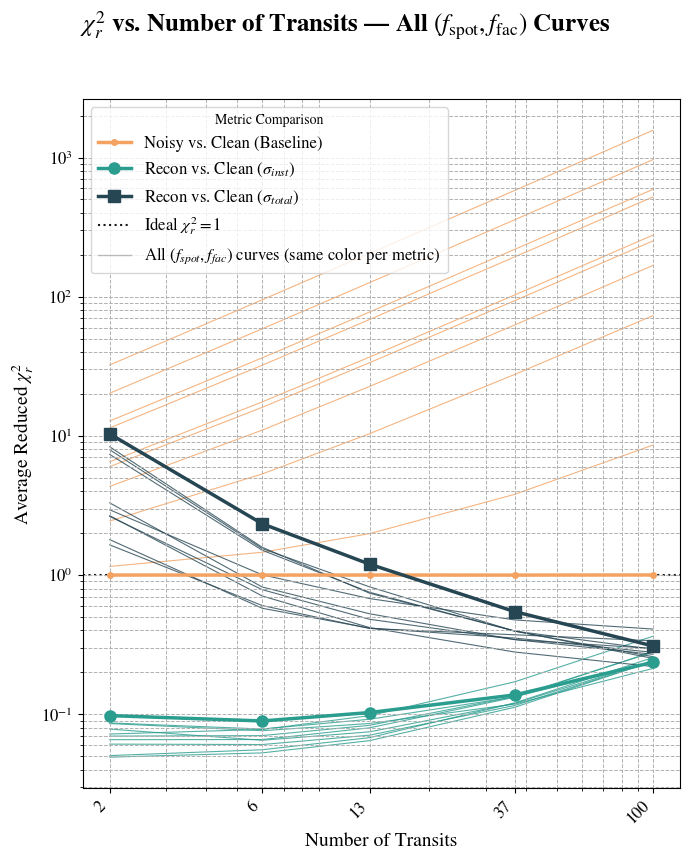

In [20]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# ============================
# Load results
# ============================
filename = 'results_by_transits_airless_vs_ch4o3h2o_proportional.pkl'
try:
    with open(filename, 'rb') as f:
        all_results = pickle.load(f)
except FileNotFoundError:
    raise RuntimeError(
        f"File '{filename}' not found. Make sure the compute script ran "
        "and the file is in the same folder."
    )

# Check the base (no contamination) exists
base_key = (0.0, 0.0)
case_base = all_results.get(base_key)
if case_base is None:
    raise RuntimeError("Missing base case (f_spot=0, f_fac=0) in results.")

# X axis (number of transits)
transits_plot = case_base['n_transits']
x_vals = np.array(transits_plot, dtype=float)

# ============================
# Plot configuration
# ============================
metrics = [
    'chi2r_noisy_clean_inst',
    'chi2r_recon_clean_inst',
    'chi2r_recon_clean_total',
]

labels = {
    'chi2r_noisy_clean_inst':  r'Noisy vs. Clean (Baseline)',
    'chi2r_recon_clean_inst':  r'Recon vs. Clean ($\sigma_{inst}$)',
    'chi2r_recon_clean_total': r'Recon vs. Clean ($\sigma_{total}$)',
}

# One color per metric; all contamination curves use the same color as their metric
palette_colors = ["#F4A261", "#2A9D8F", "#264653"]
palette = {
    'chi2r_noisy_clean_inst':  palette_colors[0],
    'chi2r_recon_clean_inst':  palette_colors[1],
    'chi2r_recon_clean_total': palette_colors[2],
}

markers = {
    'chi2r_noisy_clean_inst':  '.',
    'chi2r_recon_clean_inst':  'o',
    'chi2r_recon_clean_total': 's',
}

def series_for_metric_at_transits(data_dict, metric, transits_ref):
    """
    Return y-values for 'metric' aligned to transits_ref using the
    indexes from 'data_dict["n_transits"]'. Non-existing points -> np.nan.
    """
    ys = []
    t_list = data_dict.get('n_transits', [])
    for nt in transits_ref:
        if nt in t_list:
            idx = t_list.index(nt)
            val = data_dict[metric][idx]
        else:
            val = np.nan
        ys.append(val)
    return np.array(ys, dtype=float)

# ============================
# Make the unified plot
# ============================
fig, ax = plt.subplots(1, 1, figsize=(7, 9))
fig.suptitle(r'$\chi^2_r$ vs. Number of Transits — All $(f_{\mathrm{spot}}, f_{\mathrm{fac}})$ Curves',
             fontsize=18, y=0.98, weight='bold')

# Draw all contamination curves (thin, semi-transparent) + highlight base case
for metric in metrics:
    color = palette[metric]

    # 1) All (f_spot, f_fac) scenarios (same color, thin lines)
    #    Skip the base key for this layer; we'll plot it thicker later.
    for key, data in all_results.items():
        if key == base_key:
            continue
        if metric not in data:
            continue
        y_vals = series_for_metric_at_transits(data, metric, transits_plot)

        # Plot only if we have at least two finite points
        finite = np.isfinite(y_vals)
        if np.count_nonzero(finite) >= 2:
            ax.plot(
                x_vals[finite],
                y_vals[finite],
                lw=0.8,
                alpha=0.8,
                color=color,
                zorder=1,
            )

    # 2) Base case (thicker, markers, on top)
    y_base = series_for_metric_at_transits(case_base, metric, transits_plot)
    finite_base = np.isfinite(y_base)
    if np.count_nonzero(finite_base) >= 2:
        ax.plot(
            x_vals[finite_base],
            y_base[finite_base],
            marker=markers[metric],
            markersize=8,
            color=color,
            lw=2.5,
            label=labels[metric],
            zorder=3,
        )

# Axes, grid, legend
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'Average Reduced $\chi^2_r$', fontsize=14)
ax.set_xlabel('Number of Transits', fontsize=14)
ax.grid(True, which='both', linestyle='--', linewidth=0.7)
ax.tick_params(axis='both', which='major', labelsize=12)

# Reference line at y = 1
ax.axhline(1, color='black', linestyle=':', lw=1.5, alpha=0.9, zorder=0,
           label=r'Ideal $\chi^2_r = 1$')

# Legend: add a proxy thin line for "All contamination curves"
from matplotlib.lines import Line2D
proxy = Line2D([0], [0], lw=1.0, alpha=0.5, color='gray')
handles, labels_ax = ax.get_legend_handles_labels()
handles.append(proxy)
labels_ax.append('All $(f_{spot}, f_{fac})$ curves (same color per metric)')
ax.legend(handles=handles, labels=labels_ax, fontsize=12, loc='best',
          title="Metric Comparison")

# X tick formatting (show the actual numbers instead of scientific notation)
ax.set_xticks(x_vals)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Save figure
output_dir = 'plots'
os.makedirs(output_dir, exist_ok=True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================
# Helpers: extracción y agregación
# ==============================================================

def _safe_mean_1d(vec):
    """Mean ignorando NaNs; devuelve np.nan si todo es NaN."""
    vec = np.asarray(vec)
    if np.all(np.isnan(vec)):
        return np.nan
    return float(np.nanmean(vec))

def collect_sigma_evolution(scores_dict):
    """
    Empaqueta series por n_transits tomando promedios sobre λ.
    scores_dict: bloque all_results[(f_spot, f_fac)]
    Returns:
        n_transits: (K,)
        sig_inst:   (K,)  promedio sobre λ
        sig_ale:    (K,)  promedio sobre λ
        sig_epi:    (K,)  promedio sobre λ
        sig_total:  (K,)  promedio sobre λ
    """
    ntr = np.asarray(scores_dict["n_transits"], dtype=int)

    sig_inst = []
    sig_ale  = []
    sig_epi  = []
    sig_tot  = []

    for i in range(len(ntr)):
        inst_i = scores_dict["sigma_inst_mean_lambda"][i]  # (n_points,)
        ale_i  = scores_dict["sigma_ale_mean_lambda"][i]
        epi_i  = scores_dict["sigma_epi_mean_lambda"][i]
        tot_i  = scores_dict["sigma_total_mean_lambda"][i]

        sig_inst.append(_safe_mean_1d(inst_i))
        sig_ale.append(_safe_mean_1d(ale_i))
        sig_epi.append(_safe_mean_1d(epi_i))
        sig_tot.append(_safe_mean_1d(tot_i))

    return (
        ntr,
        np.asarray(sig_inst, dtype=float),
        np.asarray(sig_ale,  dtype=float),
        np.asarray(sig_epi,  dtype=float),
        np.asarray(sig_tot,  dtype=float),
    )

def collect_sigma_at_lambda(scores_dict, lambda_grid=None, target=None, idx=None):
    """
    Extrae la evolución por n_transits para UNA longitud de onda.
    Puedes elegir por índice (idx) o por valor cercano (target) si pasas lambda_grid.

    Returns:
        n_transits: (K,)
        sig_inst:   (K,)
        sig_ale:    (K,)
        sig_epi:    (K,)
        sig_total:  (K,)
        sel_idx:    índice de λ usado
        sel_lambda: valor de λ (None si no se pasó lambda_grid)
    """
    ntr = np.asarray(scores_dict["n_transits"], dtype=int)

    # Selección del índice de λ
    if idx is None:
        if lambda_grid is None or target is None:
            raise ValueError("Pasa idx (entero) o (lambda_grid y target) para seleccionar la λ.")
        lambda_grid = np.asarray(lambda_grid)
        sel_idx = int(np.nanargmin(np.abs(lambda_grid - target)))
    else:
        sel_idx = int(idx)

    sel_lambda = None
    if lambda_grid is not None:
        lambda_grid = np.asarray(lambda_grid)
        if sel_idx < len(lambda_grid):
            sel_lambda = float(lambda_grid[sel_idx])

    sig_inst = []
    sig_ale  = []
    sig_epi  = []
    sig_tot  = []

    for i in range(len(ntr)):
        inst_i = scores_dict["sigma_inst_mean_lambda"][i]
        ale_i  = scores_dict["sigma_ale_mean_lambda"][i]
        epi_i  = scores_dict["sigma_epi_mean_lambda"][i]
        tot_i  = scores_dict["sigma_total_mean_lambda"][i]

        # Seguridad por si hay arrays NaN placeholders
        vals = []
        for arr in (inst_i, ale_i, epi_i, tot_i):
            if arr is None or not np.isfinite(sel_idx) or sel_idx >= len(arr):
                vals.append(np.nan)
            else:
                vals.append(arr[sel_idx])

        a, b, c, d = vals
        sig_inst.append(a)
        sig_ale.append(b)
        sig_epi.append(c)
        sig_tot.append(d)

    return (
        ntr,
        np.asarray(sig_inst, dtype=float),
        np.asarray(sig_ale,  dtype=float),
        np.asarray(sig_epi,  dtype=float),
        np.asarray(sig_tot,  dtype=float),
        sel_idx,
        sel_lambda,
    )

def stack_sigma_matrix(scores_dict, key):
    """
    Apila listas de vectores (n_points,) en una matriz (K, n_points),
    donde K = número de n_transits. key ∈ {
        'sigma_inst_mean_lambda', 'sigma_ale_mean_lambda',
        'sigma_epi_mean_lambda',  'sigma_total_mean_lambda'
    }
    """
    mats = scores_dict[key]
    # Si hay NaNs placeholders, rellena con NaNs de largo máximo.
    n_points = max((len(x) for x in mats if x is not None), default=0)
    M = np.full((len(mats), n_points), np.nan, dtype=float)
    for i, arr in enumerate(mats):
        if arr is None:
            continue
        arr = np.asarray(arr, dtype=float)
        n = min(n_points, len(arr))
        M[i, :n] = arr[:n]
    return M  # shape (K, n_points)

# ==============================================================
# Plots
# ==============================================================

def plot_sigma_evolution_overall(scores_dict, title_prefix=""):
    """
    Serie temporal por n_transits del promedio (en λ) de:
    instrumental, aleatorio, epistémico, total.
    """
    ntr, s_inst, s_ale, s_epi, s_tot = collect_sigma_evolution(scores_dict)

    plt.figure(figsize=(7.5, 5.0))
    plt.plot(ntr, s_inst, marker="o", label="Instrumental (⟨σ⟩ₗ)")
    plt.plot(ntr, s_ale,  marker="o", label="Aleatoric (⟨σ⟩ₗ)")
    plt.plot(ntr, s_epi,  marker="o", label="Epistemic (⟨σ⟩ₗ)")
    plt.plot(ntr, s_tot,  marker="o", label="Total (⟨σ⟩ₗ)")
    plt.xlabel("Number of transits")
    plt.ylabel("Mean sigma over wavelength")
    ttl = f"{title_prefix} Sigma evolution (mean over λ)".strip()
    plt.title(ttl)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_sigma_evolution_at_lambda(scores_dict, lambda_grid=None, target=None, idx=None, title_prefix=""):
    """
    Serie temporal por n_transits de los sigmas en una λ específica.
    Selecciona con idx (entero) o con target+lambda_grid.
    """
    (ntr, s_inst, s_ale, s_epi, s_tot, sel_idx, sel_lambda) = collect_sigma_at_lambda(
        scores_dict, lambda_grid=lambda_grid, target=target, idx=idx
    )

    label_lambda = f"λ index {sel_idx}" if sel_lambda is None else f"λ={sel_lambda:.4f} (idx {sel_idx})"

    plt.figure(figsize=(7.5, 5.0))
    plt.plot(ntr, s_inst, marker="o", label=f"Instrumental @ {label_lambda}")
    plt.plot(ntr, s_ale,  marker="o", label=f"Aleatoric @ {label_lambda}")
    plt.plot(ntr, s_epi,  marker="o", label=f"Epistemic @ {label_lambda}")
    plt.plot(ntr, s_tot,  marker="o", label=f"Total @ {label_lambda}")
    plt.xlabel("Number of transits")
    plt.ylabel("Sigma at chosen wavelength")
    ttl = f"{title_prefix} Sigma evolution at {label_lambda}".strip()
    plt.title(ttl)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_sigma_heatmap(scores_dict, key, lambda_grid=None, title_prefix=""):
    """
    Heatmap (imshow) de sigma_mean_lambda (nt × λ).
    key ∈ {'sigma_inst_mean_lambda','sigma_ale_mean_lambda',
           'sigma_epi_mean_lambda','sigma_total_mean_lambda'}
    """
    M = stack_sigma_matrix(scores_dict, key)  # shape (K, n_points)
    ntr = np.asarray(scores_dict["n_transits"], dtype=int)
    if M.size == 0:
        raise ValueError("No data to plot.")

    plt.figure(figsize=(8.5, 4.8))
    im = plt.imshow(M, aspect="auto", origin="lower")
    plt.colorbar(im, label=f"{key} (mean per λ)")
    plt.yticks(ticks=np.arange(len(ntr)), labels=[str(x) for x in ntr])
    plt.ylabel("Number of transits (rows)")
    if lambda_grid is not None:
        # Mostrar ticks parciales (p.ej., cada ~N/6 puntos)
        L = M.shape[1]
        lambda_grid = np.asarray(lambda_grid)
        if len(lambda_grid) == L:
            step = max(1, L // 6)
            xt = np.arange(0, L, step)
            plt.xticks(ticks=xt, labels=[f"{lambda_grid[i]:.3f}" for i in xt], rotation=45, ha="right")
            plt.xlabel("Wavelength")
        else:
            plt.xlabel("Wavelength index")
    else:
        plt.xlabel("Wavelength index")
    ttl = f"{title_prefix} {key} heatmap (rows: n_transits, cols: λ)".strip()
    plt.title(ttl)
    plt.tight_layout()
    plt.show()


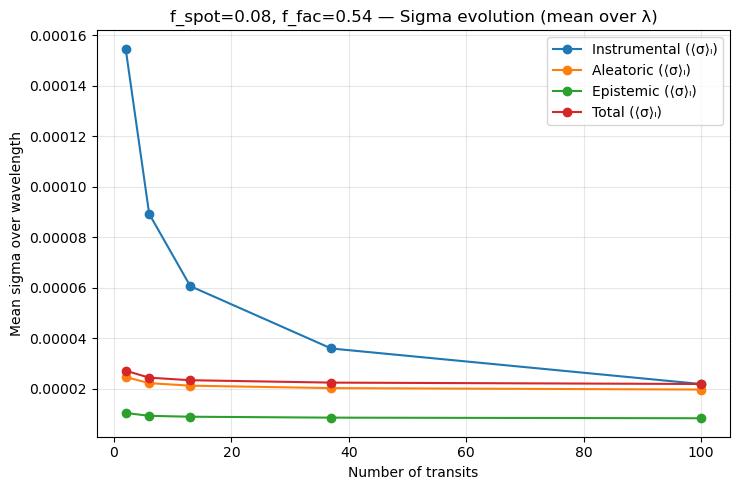

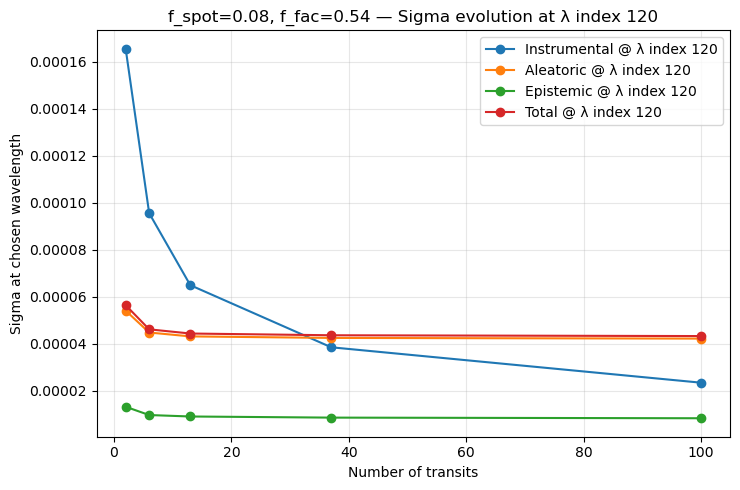

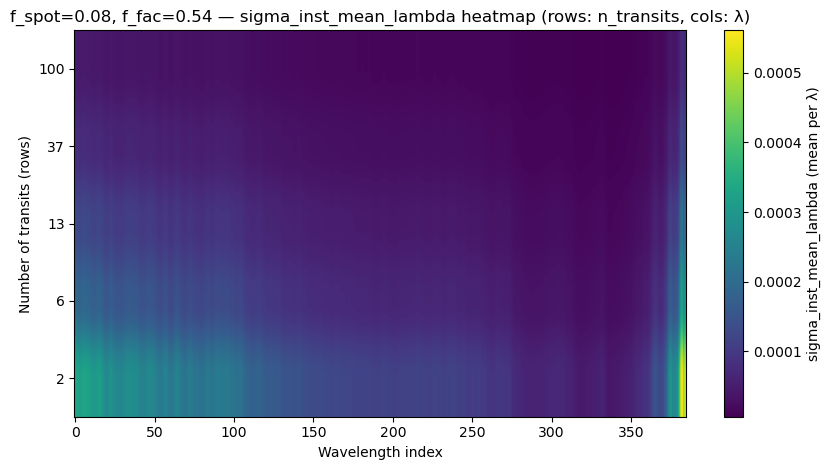

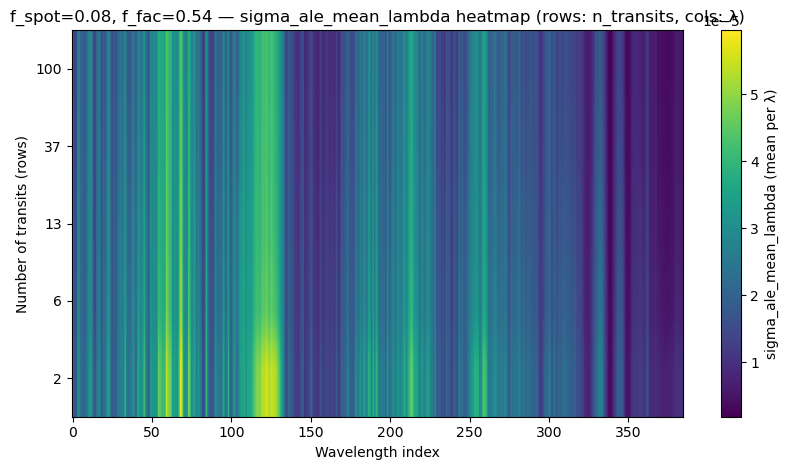

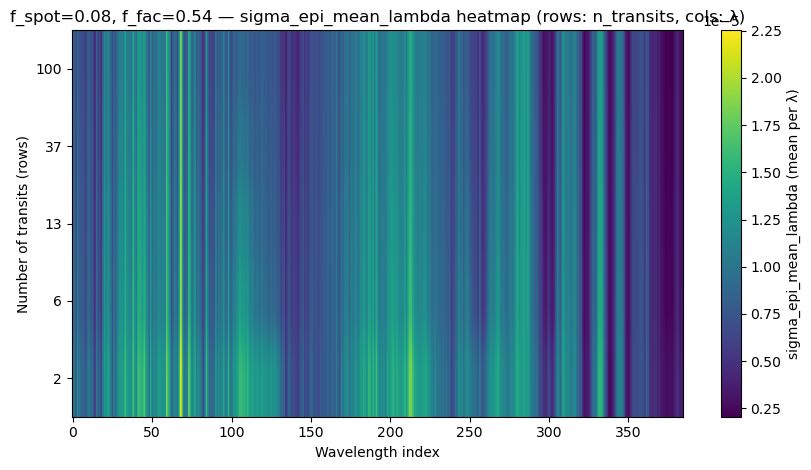

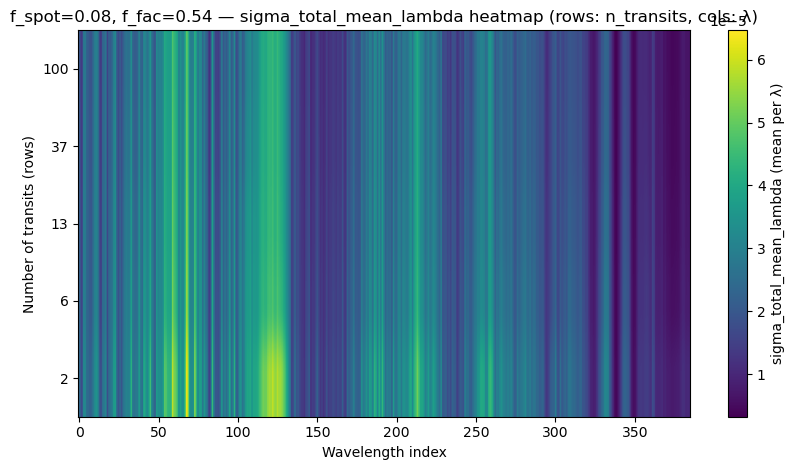

In [23]:
# 1) Escoge la combinación (f_spot, f_fac) que quieras:
scores = all_results[(0.08, 0.54)]

# 2) Evolución global (promedio sobre λ):
plot_sigma_evolution_overall(scores, title_prefix="f_spot=0.08, f_fac=0.54 —")

# 3) Evolución en una λ específica:
# 3a) Por índice (ej. el bin 120)
plot_sigma_evolution_at_lambda(scores, idx=120, title_prefix="f_spot=0.08, f_fac=0.54 —")

# 3b) Por valor de longitud de onda más cercano (si tienes lambda_grid del espectro):
# lambda_grid = np.loadtxt("wavelength_grid.txt")  # por ejemplo
# plot_sigma_evolution_at_lambda(scores, lambda_grid=lambda_grid, target=3.5, title_prefix="...")

# 4) Heatmaps para ver nt × λ:
plot_sigma_heatmap(scores, key="sigma_inst_mean_lambda", title_prefix="f_spot=0.08, f_fac=0.54 —")
plot_sigma_heatmap(scores, key="sigma_ale_mean_lambda",  title_prefix="f_spot=0.08, f_fac=0.54 —")
plot_sigma_heatmap(scores, key="sigma_epi_mean_lambda",  title_prefix="f_spot=0.08, f_fac=0.54 —")
plot_sigma_heatmap(scores, key="sigma_total_mean_lambda",title_prefix="f_spot=0.08, f_fac=0.54 —")


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# ==============================================================
# Helpers de extracción/agrupación
# ==============================================================

SIGMA_KEYS = [
    "sigma_inst_mean_lambda",
    "sigma_ale_mean_lambda",
    "sigma_epi_mean_lambda",
    "sigma_total_mean_lambda",
]

def _safe_mean_1d(vec):
    vec = np.asarray(vec, dtype=float)
    return np.nan if vec.size == 0 or np.all(np.isnan(vec)) else float(np.nanmean(vec))

def _per_transit_scalar_series(scores_dict, sigma_key):
    """
    Toma el bloque scores de una combinación y devuelve:
      - ntr: (K,)
      - series: (K,) con el promedio ESCALAR por tránsito,
                calculado como mean(sigma_mean_lambda) sobre λ.
    """
    if sigma_key not in SIGMA_KEYS:
        raise ValueError(f"sigma_key inválido: {sigma_key}")

    ntr = np.asarray(scores_dict["n_transits"], dtype=int)
    series = []
    for i in range(len(ntr)):
        vec_lambda = scores_dict[sigma_key][i]  # (n_points,) o NaNs si placeholder
        series.append(_safe_mean_1d(vec_lambda))
    return ntr, np.asarray(series, dtype=float)

def _collect_all_combo_series(all_results, sigma_key):
    """
    Reúne, para TODAS las combinaciones (f_spot, f_fac), la serie escalar por tránsito.
    Devuelve:
      combos: list of (f_spot, f_fac)
      ntrs:   array (K,)  (asume mismo N_TRANSITS en todos los bloques)
      M:      matriz (num_combos, K) con el valor escalar por tránsito por combo
    """
    combos = list(all_results.keys())
    if not combos:
        raise ValueError("all_results está vacío.")

    # Usamos el primero como referencia de n_transits
    ntr_ref = np.asarray(all_results[combos[0]]["n_transits"], dtype=int)

    M = []
    good_combos = []
    for combo in combos:
        scores = all_results[combo]
        ntr, s = _per_transit_scalar_series(scores, sigma_key)
        # Aseguramos alineación de tránsitos
        if len(ntr) != len(ntr_ref) or np.any(ntr != ntr_ref):
            raise RuntimeError(f"n_transits no coincide para la combinación {combo}.")
        M.append(s)
        good_combos.append(combo)

    M = np.vstack(M)  # (C, K)
    return good_combos, ntr_ref, M

# ==============================================================
# Plots
# ==============================================================

def plot_sigma_overall_average(all_results, sigma_key, title_prefix=""):
    """
    Promedio global: primero mean sobre λ (ya lo hace el bloque por tránsito),
    luego mean sobre combinaciones (f_spot,f_fac).
    """
    combos, ntr, M = _collect_all_combo_series(all_results, sigma_key)
    overall = np.nanmean(M, axis=0)

    plt.figure(figsize=(7.5, 5.0))
    plt.plot(ntr, overall, marker="o", label="Overall avg across (f_spot, f_fac)")
    plt.xlabel("Number of transits")
    plt.ylabel(f"Mean {sigma_key} (scalar)")
    ttl = f"{title_prefix} Overall evolution of {sigma_key}".strip()
    plt.title(ttl)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_sigma_by_combo(all_results, sigma_key, title_prefix=""):
    """
    Curvas por combinación (f_spot,f_fac). Cada curva es el promedio escalar por tránsito.
    """
    combos, ntr, M = _collect_all_combo_series(all_results, sigma_key)

    plt.figure(figsize=(8.5, 5.5))
    for (fs, ff), row in zip(combos, M):
        label = f"f_spot={fs:g}, f_fac={ff:g}"
        plt.plot(ntr, row, marker="o", label=label)
    plt.xlabel("Number of transits")
    plt.ylabel(f"Mean {sigma_key} (scalar)")
    ttl = f"{title_prefix} Evolution by (f_spot, f_fac): {sigma_key}".strip()
    plt.title(ttl)
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

def plot_sigma_heatmap_combo_vs_transits(all_results, sigma_key, title_prefix=""):
    """
    Heatmap con filas = combinaciones (f_spot,f_fac) y columnas = n_transits.
    La celda es el promedio escalar (mean sobre λ) de ese sigma para esa combinación y tránsito.
    """
    combos, ntr, M = _collect_all_combo_series(all_results, sigma_key)
    # Orden opcional de combos por (f_spot, f_fac) para lectura
    order = np.argsort([ (fs, ff) for (fs, ff) in combos ])
    M_ord = M[order]
    combos_ord = [combos[i] for i in order]

    plt.figure(figsize=(9.5, 6.0))
    im = plt.imshow(M_ord, aspect="auto", origin="lower")
    plt.colorbar(im, label=f"{sigma_key} (mean over λ)")
    # Ejes
    plt.xticks(ticks=np.arange(len(ntr)), labels=[str(x) for x in ntr], rotation=0)
    ylabels = [f"fs={fs:g}, ff={ff:g}" for (fs, ff) in combos_ord]
    plt.yticks(ticks=np.arange(len(combos_ord)), labels=ylabels)
    plt.xlabel("Number of transits")
    plt.ylabel("Combinations (f_spot, f_fac)")
    ttl = f"{title_prefix} {sigma_key}: combos × transits".strip()
    plt.title(ttl)
    plt.tight_layout()
    plt.show()

# ==============================================================
# Atajos para ploteo múltiple
# ==============================================================

def plot_all_sigmas_overall(all_results, title_prefix=""):
    for key in SIGMA_KEYS:
        plot_sigma_overall_average(all_results, key, title_prefix=title_prefix)

def plot_all_sigmas_by_combo(all_results, title_prefix=""):
    for key in SIGMA_KEYS:
        plot_sigma_by_combo(all_results, key, title_prefix=title_prefix)

def plot_all_sigmas_heatmaps(all_results, title_prefix=""):
    for key in SIGMA_KEYS:
        plot_sigma_heatmap_combo_vs_transits(all_results, key, title_prefix=title_prefix)


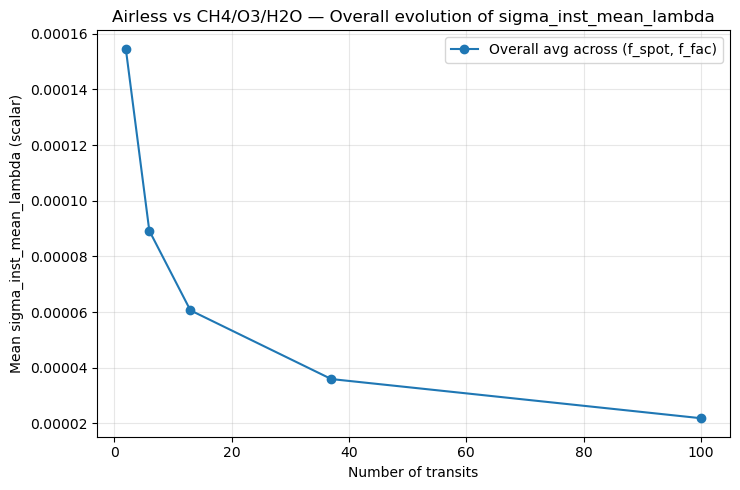

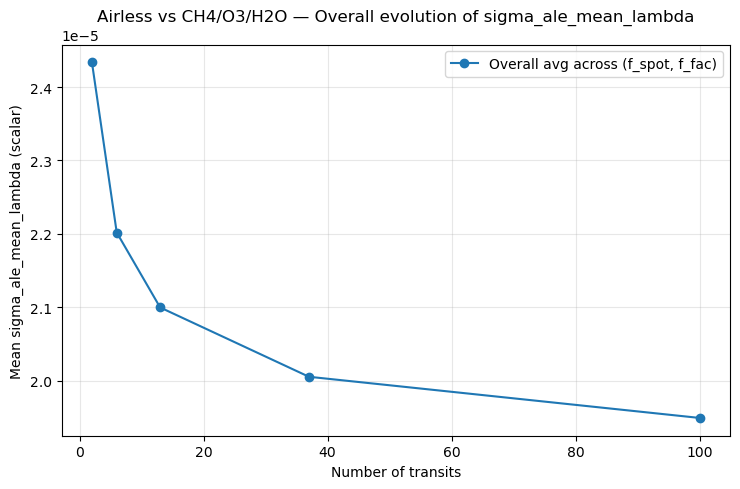

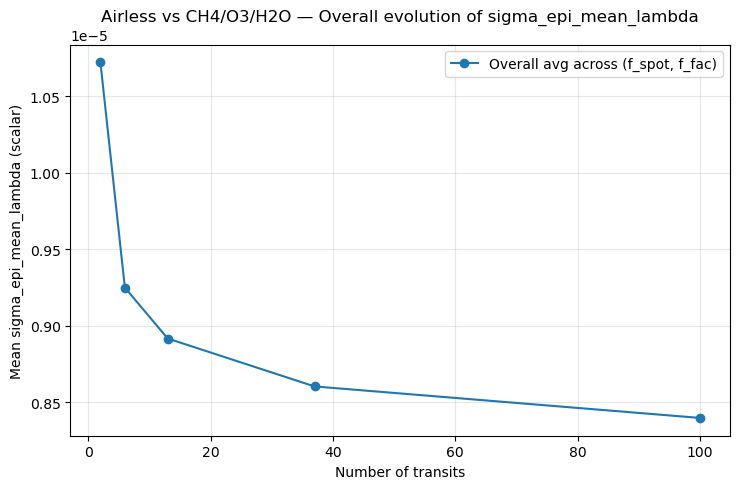

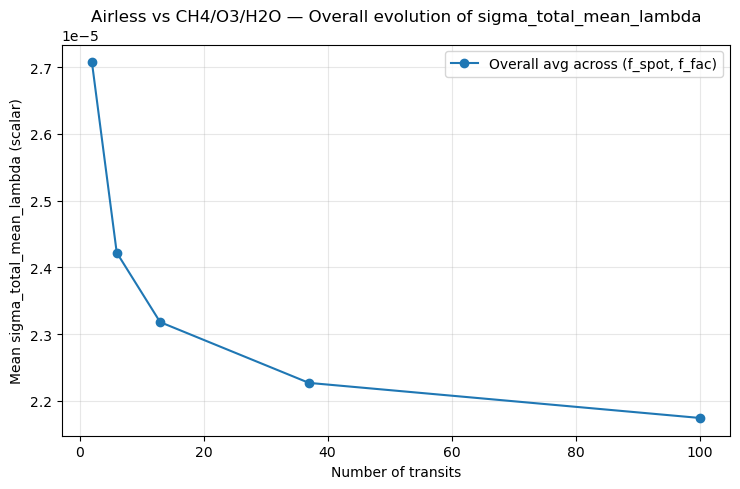

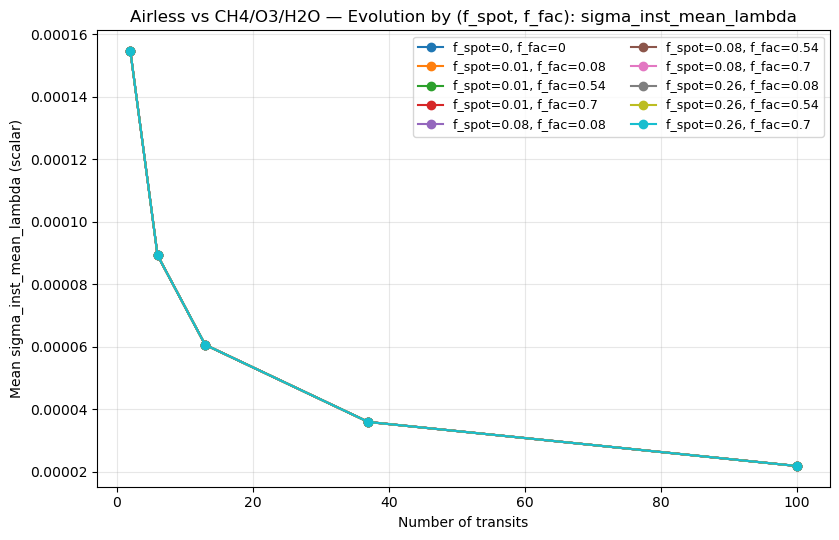

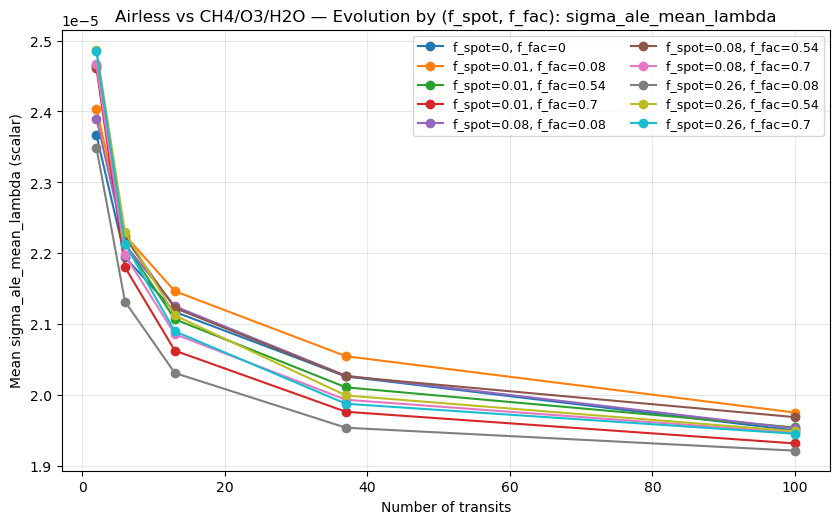

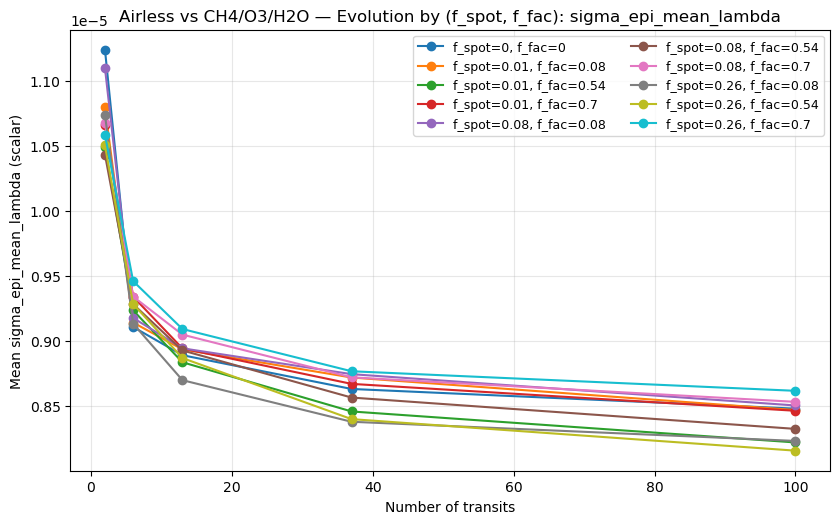

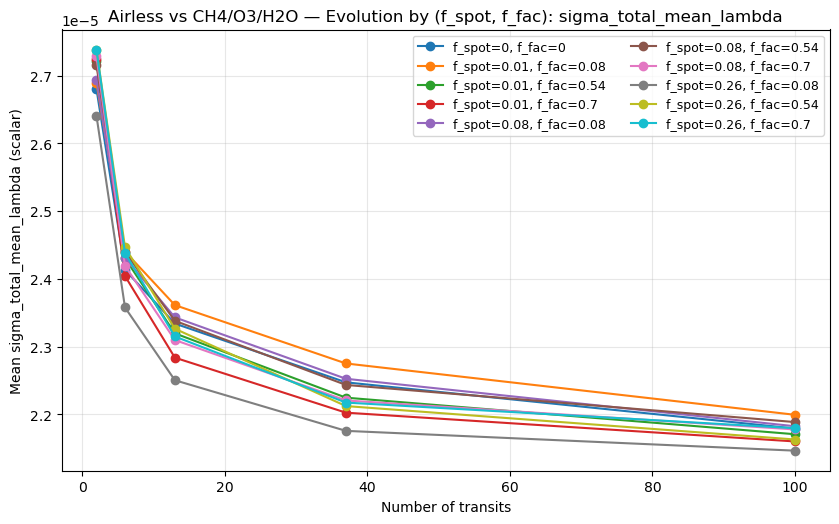

c:\Users\User\anaconda3\Lib\site-packages\executing\executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
c:\Users\User\anaconda3\Lib\ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)


TypeError: only integer scalar arrays can be converted to a scalar index

In [25]:
# A) Promedio global (todas las combinaciones juntas) — por cada sigma:
plot_all_sigmas_overall(all_results, title_prefix="Airless vs CH4/O3/H2O —")

# B) Promedio diferenciado por combinación (cada par f_spot–f_fac en una curva):
plot_all_sigmas_by_combo(all_results, title_prefix="Airless vs CH4/O3/H2O —")

# C) Heatmaps (filas = combinaciones, columnas = n_transits):
plot_all_sigmas_heatmaps(all_results, title_prefix="Airless vs CH4/O3/H2O —")

# D) Si quieres solo uno específico, por ejemplo el total:
plot_sigma_overall_average(all_results, "sigma_total_mean_lambda",
                           title_prefix="Airless vs CH4/O3/H2O —")
plot_sigma_by_combo(all_results, "sigma_total_mean_lambda",
                    title_prefix="Airless vs CH4/O3/H2O —")
plot_sigma_heatmap_combo_vs_transits(all_results, "sigma_total_mean_lambda",
                                     title_prefix="Airless vs CH4/O3/H2O —")
